<a href="https://colab.research.google.com/github/Luuuuuig/Bachelor-End-Project/blob/main/Arno_Analysis_2026_10_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arno's purchasing work: analysis of five observation sessions
**2 October 2026 · Review draft · Five sessions, 31 August to 23 September**

This notebook starts the Analyze phase requested in the 1 October meeting. It loads and cleans the observation records, then asks one question at a time. Each part builds on the one before it.

## Summary

- **Ordering takes the most time** (part 2): 340 of 742 recorded minutes (45.8%), or 59.6% without former EXC work. It is the largest stage on every day. A stage is a focus area, not yet a selected AI task.
- **Former EXC work stays in the total** (part 2): 182 minutes (24.5%), shown as "OTHER (outside improvement)" and not considered for AI improvement.
- **CHECK takes about 0.87 minutes per order line** (part 3): 62 minutes for 71 lines. Daily ratios vary and most line counts are order sizes, so this is exploratory.
- **Three improvement candidates stand out** (parts 5 and 8): creating or completing PO lines (112 minutes, 35 cases), purchase-price control (98 minutes, 19 cases) and request intake & validation (94 minutes, 11 cases). Each holds 17–20% of the 560 minutes inside the improvement scope.
- **Many cases are picked up again** (part 6): 29 of 98 cases (30%), holding 46% of the minutes. For POs this is often on purpose: Arno leaves a non-urgent order open to add later demand (part 9).
- **Problems are spread thin** (part 7): 19 of 98 cases record a problem, no problem type occurs in more than 4 cases inside the improvement scope, and cases without a recorded problem hold 72.5% of the minutes.
- **The causes differ by candidate** (part 9): for PO lines the time is not in typing but in orders held open for maximalisatie and in incomplete or wrong data in Exact. Price control is manual comparison, because Exact cannot compare documents and its prices are not kept up to date. Request intake is incomplete input with no clear single source. Yijie answered most questions on 2 October; Arno still has to confirm.
- **No candidate is selected yet** (part 8): scoring waits until the anchors and weights are agreed with Zhongxin.
- **Parts 5 to 8 rest on the kinds-of-work labels**, which a second coder has not yet checked (part 4). Treat those results as provisional.

## How this notebook is organised

| Part | Question | What it leads to |
|---|---|---|
| 1. Load and prepare the data | Read the five days, calculate durations, group the activity codes and apply the 1 October scope decisions | Clean records for every later part |
| 2. Where does the time go? | Time by activity code, by purchasing stage and per day | Ordering is the largest stage |
| 3. A closer look at Ordering and CHECK | What the notes inside Ordering describe; CHECK time per order line | One activity code covers several different tasks |
| 4. From activity codes to specific tasks | Why a finer label is needed, where the kinds of work come from, how they fit the purchasing framework and how reliable they are | A task label for almost every record |
| 5. Which specific tasks take the time? | Time and frequency per task | The largest tasks |
| 6. How does a case flow? | Order of activities, interruptions, where work was left | Interrupted cases take longer |
| 7. Where do problems recur? | Which problems the notes record, how often and in which cases | Problems are spread thin |
| 8. Comparing the improvement candidates | Observed evidence per candidate, without scoring | What still needs company input |
| 9. Why does the time go there? | Draft causes for the three largest candidates, in fishbone diagrams | Questions for the session with Arno |

## Context & Methods

**Question:** where does Arno's observed purchasing work concentrate, and which specific tasks deserve closer investigation under the supervisor's clarified scope?

The [1 October minutes](https://github.com/Luuuuuig/Bachelor-End-Project/blob/main/docs/meetings/Academic_Supervisor_Meeting_Notes_2026-10-01.md) establish four working decisions: start with Arno, retain aftercare under OTHER but outside improvement scope, retain work outside the purchasing framework, and compare CHECK with order-line volume before reconsidering stability. Dennis can be revisited later.

The methods follow a descriptive EDA workflow: load and inspect records, group and sum, compare distributions, inspect cases, plot relationships and calculate pooled ratios. No hypothesis test, regression, new pass/fail rule or saturation claim is needed for these questions.

### Key Assumptions

| Choice | Treatment |
|---|---|
| Unit of analysis | A recorded activity segment or tally; a row is not necessarily a complete task or order. |
| Duration | End minus start when both are recorded; otherwise missing, never imputed as zero or one minute. |
| Lost focus | Preserve the two 8 September OBS-16 rows, but exclude their nine minutes and rows from descriptive comparisons. |
| EXC | Report under OTHER as "OTHER (outside improvement)", separate from original OTHER; the original code stays in the `Activity` column. |
| Stage | Use the stage written in the CSV; keep blanks as Unassigned. |
| Percentage denominator | Sum of retained recorded activity durations, including EXC and work outside the framework. |
| CHECK line volume | Use explicit checked-line counts where given; otherwise an order-size proxy. Correct split segments and exclude documented incomplete checks from ratios only. |
| Kinds of work | Labels from 30 September, up to three per record (part 4). A record's minutes count under each of its kinds, so totals per kind overlap. |
| Generalisation | These are five sessions for one buyer; dates, case labels and repeated segments are not independent random samples of all purchasing work. |

**Sources.** The five daily CSVs are loaded from commit [`0510b1c`](https://github.com/Luuuuuig/Bachelor-End-Project/commit/0510b1cb1edc6d5cc6af40c18c903d1052eab7fe), which records 1 September OBS-02 REQ (10:49–10:50) as an untimed tally. Yijie confirmed this change on 2 October; see the dated note in the [1 September observation notes](https://github.com/Luuuuuig/Bachelor-End-Project/blob/main/docs/measurement/Measure_Observation_2026-09-01.md#observer-decision-2-october-2026). The kinds-of-work labels (part 4) are loaded from commit [`dccb45a`](https://github.com/Luuuuuig/Bachelor-End-Project/commit/dccb45aef1d190f9845a6831764e5c21cca1edca), where they were created on 30 September. All code is in this notebook.

## 1. Load and prepare the data

Each observation day is one CSV file: the original eight observation columns plus the reviewed Van Weele stage. This part combines the five days, calculates durations and applies the decisions of 1 October. Only the lost-focus episode on 8 September is set aside; no other record is removed.

In [1]:
import pandas as pd

# GitHub version containing your REQ correction
commit = "0510b1cb1edc6d5cc6af40c18c903d1052eab7fe"
base_url = (
    "https://raw.githubusercontent.com/"
    f"Luuuuuig/Bachelor-End-Project/{commit}/docs/measurement/"
)

dates = [
    "2026-08-31",
    "2026-09-01",
    "2026-09-08",
    "2026-09-18",
    "2026-09-23"
]

# Read each day and make the column names consistent
frames = []

for date in dates:
    df = pd.read_csv(
        base_url + f"Arno_Measurement_{date}.csv",
        encoding="utf-8-sig",
        na_values=["—"]
    )

    df = df.rename(columns={
        "Activity as written": "Activity",
        "Result / short note": "Note"
    })

    df["date"] = pd.to_datetime(date)
    df["source_row"] = df.index + 1
    frames.append(df)

# Combine the five days
observations = pd.concat(frames, ignore_index=True)
observations["weekday"] = observations["date"].dt.day_name()

# Calculate durations. Untimed tallies remain missing, not zero.
start = pd.to_datetime(
    observations["Start"], format="%H:%M", errors="coerce"
)
end = pd.to_datetime(
    observations["End"], format="%H:%M", errors="coerce"
)

observations["minutes"] = (end - start).dt.total_seconds() / 60

# Exclude the documented lost-focus episode from analysis
lost_focus = (
    observations["date"].eq(pd.Timestamp("2026-09-08"))
    & observations["Case"].eq("OBS-16")
)

included = observations.loc[~lost_focus].copy()

print("Original records:", len(observations))
print("Records included:", len(included))
print("Recorded minutes:", included["minutes"].sum())

included.head()

Original records: 287
Records included: 285
Recorded minutes: 742.0


,Case,Activity,Start,End,Volume,INT,DEC?,Note,Van Weele stage,date,source_row,weekday,minutes
0,OBS-01,REQ,NaN,NaN,NaN,0,NaN,Item: Primer-C. Request received via physical ...,Specification,2026-08-31,1,Monday,NaN
1,OBS-01,CLAR,10:30,10:40,1L,1,Yes,NaN,Specification,2026-08-31,2,Monday,10.0
2,OBS-02,REQ-mail,NaN,NaN,NaN,0,NaN,NaN,Ordering,2026-08-31,3,Monday,NaN
3,OBS-02,PO,10:42,10:44,1L,0,NaN,NaN,Ordering,2026-08-31,4,Monday,2.0
4,OBS-02,SEND,10:46,10:51,1L,0,NaN,Error Exact,Ordering,2026-08-31,5,Monday,5.0


### Group the activity codes and apply the scope decisions

Codes are written with suffixes such as REQ-mail and REQ-phone, so they are grouped by their first part. Following 1 October, former EXC records go under OTHER as "OTHER (outside improvement)": their time stays in the total, but they are not considered for AI improvement. Records without a stage stay visible as "Unassigned".

In [2]:
# Group variants such as REQ-mail and REQ-phone under REQ
# Keep the original Activity column unchanged
included["activity_group"] = (
    included["Activity"]
    .fillna("UNCLEAR")
    .str.upper()
    .str.strip()
    .str.split("-")
    .str[0]
)

# Apply the supervisor's EXC → OTHER decision
included["activity_group"] = included["activity_group"].replace({
    "EXC": "OTHER",
    "OTHER/EXC": "OTHER",
    "[UNCERTAIN]": "UNCLEAR"
})

# Former EXC stays under OTHER but outside the improvement scope (1 October)
is_former_exc = included["Activity"].str.upper().str.contains("EXC", na=False)
included.loc[is_former_exc, "activity_group"] = "OTHER (outside improvement)"

# Purchasing stage; rows without a stage stay visible as "Unassigned"
included["stage"] = included["Van Weele stage"].fillna("Unassigned")

included["activity_group"].value_counts()

activity_group
PO                             63
REQ                            49
SEND                           43
CLAR                           42
OTHER (outside improvement)    41
OTHER                          22
CHECK                          21
DEC                             3
UNCLEAR                         1
Name: count, dtype: int64

## 2. Where does the time go?

Three views of the same 742 recorded minutes: by activity code, by purchasing stage, and by stage per day. Untimed tallies count as records but have no minutes.

In [3]:
# Summarise counts and measured time separately
groups = included.groupby("activity_group")["minutes"]

profile = pd.DataFrame({
    "records": groups.size(),
    "timed_records": groups.count(),
    "minutes": groups.sum(min_count=1)
})

profile["untimed_records"] = (
    profile["records"] - profile["timed_records"]
)

profile["share_pct"] = (
    profile["minutes"] / included["minutes"].sum() * 100
)

profile = profile[
    ["records", "timed_records", "untimed_records", "minutes", "share_pct"]
].sort_values("minutes", ascending=False)

profile.round(1)

,records,timed_records,untimed_records,minutes,share_pct
activity_group,,,,,
OTHER (outside improvement),41,40,1,182.0,24.5
PO,63,62,1,165.0,22.2
CLAR,42,41,1,155.0,20.9
CHECK,21,21,0,91.0,12.3
OTHER,22,21,1,77.0,10.4
SEND,43,36,7,71.0,9.6
UNCLEAR,1,1,0,1.0,0.1
DEC,3,0,3,NaN,NaN
REQ,49,0,49,NaN,NaN


In [4]:
# Recorded time per purchasing stage
stage_profile = (
    included.groupby("stage")["minutes"]
    .sum(min_count=1)
    .to_frame("minutes")
)

# Share of all recorded work, and share when former EXC minutes are left out
without_former_exc = included.loc[~is_former_exc]
stage_profile["share_pct"] = (
    stage_profile["minutes"] / included["minutes"].sum() * 100
)
stage_profile["share_excl_former_exc_pct"] = (
    without_former_exc.groupby("stage")["minutes"].sum(min_count=1)
    / without_former_exc["minutes"].sum() * 100
)

stage_profile = stage_profile.sort_values("minutes", ascending=False)

stage_profile.round(1)

,minutes,share_pct,share_excl_former_exc_pct
stage,,,
Ordering,340.0,45.8,59.6
Monitoring,112.0,15.1,13.8
Unassigned,89.0,12.0,7.3
Not applicable,71.0,9.6,4.6
Follow-up and evaluation,69.0,9.3,3.8
Specification,47.0,6.3,8.4
Supplier selection,14.0,1.9,2.5


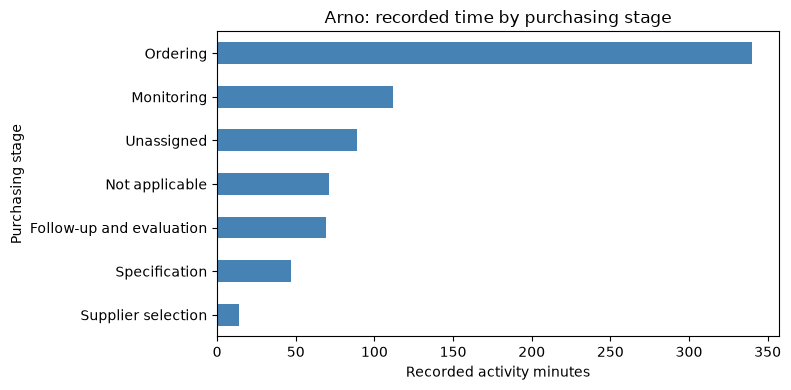

In [5]:
import matplotlib.pyplot as plt

stage_profile["minutes"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    color="steelblue"
)

plt.xlabel("Recorded activity minutes")
plt.ylabel("Purchasing stage")
plt.title("Arno: recorded time by purchasing stage")
plt.tight_layout()
plt.show()

In [6]:
# Sum minutes for each combination of day and stage
daily_minutes = (
    included.groupby(["date", "stage"])["minutes"]
    .sum(min_count=1)
    .unstack(fill_value=0)
)

# Calculate percentages within each day
daily_totals = included.groupby("date")["minutes"].sum(min_count=1)

daily_shares = daily_minutes.div(daily_totals, axis=0) * 100

# Use the same stage order as the overall profile
daily_shares = daily_shares.reindex(columns=stage_profile.index)

daily_shares.round(1)

stage,Ordering,Monitoring,Unassigned,Not applicable,Follow-up and evaluation,Specification,Supplier selection
date,,,,,,,
2026-08-31,67.0,13.6,4.9,0.0,1.9,12.6,0.0
2026-09-01,51.6,9.3,12.4,0.0,13.0,13.7,0.0
2026-09-08,39.2,0.0,18.6,2.1,29.9,6.2,4.1
2026-09-18,41.3,38.3,1.5,5.1,8.7,0.0,5.1
2026-09-23,37.3,4.3,23.2,31.9,0.0,3.2,0.0


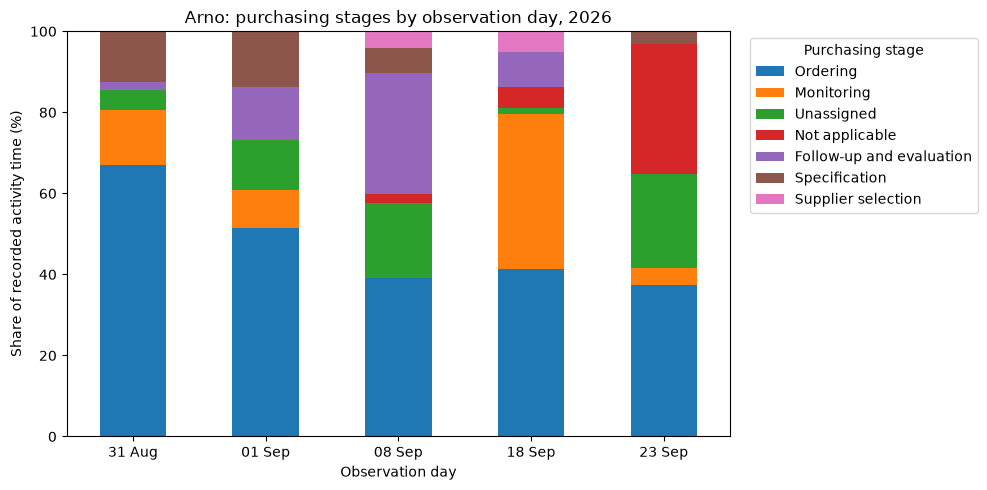

In [7]:
plot_data = daily_shares.copy()
plot_data.index = plot_data.index.strftime("%d %b")

plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.xlabel("Observation day")
plt.ylabel("Share of recorded activity time (%)")
plt.title("Arno: purchasing stages by observation day, 2026")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(
    title="Purchasing stage",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

**Reading.**

- **Former EXC work is the largest single group** (182 minutes, 24.5%); it stays in the total but is outside the improvement scope. **PO (165 minutes) and CLAR (155)** are the largest codes inside the scope.
- **Ordering is the largest stage:** 340 minutes (45.8%), or 59.6% without former EXC. It is the largest stage on every day, although its daily share ranges from 37% to 67%. Monitoring comes close on 18 September (38%), when two large orders were checked, and work outside the purchasing framework does on 23 September (32%).

**Next.** Ordering is where to look first. But PO and CLAR are broad codes, so part 3 reads the notes inside Ordering.

## 3. A closer look at Ordering and CHECK

First the activity codes and notes inside Ordering, then a few example cases chosen after reading the notes. The second half follows the 1 October action: compare CHECK time with the number of order lines.

In [8]:
# Select records assigned to Ordering
ordering = included.loc[included["stage"] == "Ordering"].copy()

# Summarise activities within Ordering
groups = ordering.groupby("activity_group")["minutes"]

ordering_profile = pd.DataFrame({
    "records": groups.size(),
    "timed_records": groups.count(),
    "minutes": groups.sum(min_count=1)
})

ordering_profile["untimed_records"] = (
    ordering_profile["records"] - ordering_profile["timed_records"]
)

# The denominator is now Ordering time, not total activity time
ordering_profile["share_within_ordering_pct"] = (
    ordering_profile["minutes"] / ordering["minutes"].sum() * 100
)

ordering_profile = ordering_profile.sort_values(
    "minutes", ascending=False
)

ordering_profile.round(1)

,records,timed_records,minutes,untimed_records,share_within_ordering_pct
activity_group,,,,,
PO,62,61,161.0,1,47.4
CLAR,22,21,63.0,1,18.5
SEND,29,25,49.0,4,14.4
CHECK,6,6,37.0,0,10.9
OTHER,9,8,24.0,1,7.1
OTHER (outside improvement),1,1,6.0,0,1.8
DEC,3,0,NaN,3,NaN
REQ,31,0,NaN,31,NaN


In [9]:
ordering_notes = ordering.loc[
    ordering["activity_group"].isin(["PO", "CLAR"]),
    ["date", "Case", "source_row", "activity_group", "minutes", "Note"]
].sort_values(["date", "source_row"])

# Show the first 20 records with readable notes
with pd.option_context("display.max_colwidth", 180):
    display(ordering_notes.head(20))

,date,Case,source_row,activity_group,minutes,Note
3,2026-08-31,OBS-02,4,PO,2.0,NaN
6,2026-08-31,OBS-03,7,CLAR,NaN,"Forward; instantaneous/tally occurrence, not a timed episode."
9,2026-08-31,OBS-04,10,PO,2.0,1L added
16,2026-08-31,OBS-06,17,PO,4.0,NaN
19,2026-08-31,OBS-07,20,CLAR,2.0,Write up information
24,2026-08-31,OBS-07,25,CLAR,2.0,2nd item that needs be inputted; asking question
25,2026-08-31,OBS-07,26,CLAR,4.0,"2nd item, different comp."
28,2026-08-31,OBS-08,29,PO,1.0,Buy order amount of €900
31,2026-08-31,OBS-09,32,PO,1.0,"Buy amount of €2,000"
34,2026-08-31,OBS-10,35,CLAR,2.0,Credit-card action. This is a one-time purchase that is paid via credit card instead of the normal purchasing process. This case = 1 PC.


In [10]:
# Examples selected after reviewing the notes
review_cases = pd.DataFrame([
    ["2026-09-18", "OBS-10", "Drawing completeness"],
    ["2026-09-23", "OBS-12", "Drawing completeness"],
    ["2026-09-01", "OBS-02", "Quantity clarification"],
    ["2026-08-31", "OBS-07", "Item data completeness"],
    ["2026-09-01", "31AUG-OBS-07", "Item data completeness"],
    ["2026-08-31", "OBS-15", "MAX / combining demand"],
    ["2026-09-23", "OBS-19", "MAX / combining demand"]
], columns=["date", "Case", "reason_for_review"])

review_cases["date"] = pd.to_datetime(review_cases["date"])

# Retrieve all recorded activities belonging to these examples
case_details = included.merge(
    review_cases,
    on=["date", "Case"],
    how="inner",
    validate="many_to_one"
)

case_details = case_details[[
    "reason_for_review", "date", "Case", "source_row",
    "activity_group", "minutes", "Note"
]].sort_values(["reason_for_review", "date", "source_row"])

with pd.option_context(
    "display.max_colwidth", 180,
    "display.max_rows", None
):
    display(case_details)

,reason_for_review,date,Case,source_row,activity_group,minutes,Note
17,Drawing completeness,2026-09-18,OBS-10,26,REQ,NaN,NaN
18,Drawing completeness,2026-09-18,OBS-10,27,PO,7.0,Prepare drawings to attach to the PO; write down which drawings are missing.
19,Drawing completeness,2026-09-18,OBS-10,28,CLAR,2.0,Look for the relevant drawings and ask the engineer for them.
20,Drawing completeness,2026-09-18,OBS-10,40,SEND,2.0,Drawing received from the engineer.
21,Drawing completeness,2026-09-18,OBS-10,41,CLAR,4.0,Final check that the drawing and its information were complete.
22,Drawing completeness,2026-09-23,OBS-12,32,REQ,NaN,NaN
23,Drawing completeness,2026-09-23,OBS-12,33,PO,5.0,See the separate case note below.
24,Drawing completeness,2026-09-23,OBS-12,34,CLAR,5.0,"Look for the relevant drawing; unable to find it, ask a colleague."
25,Drawing completeness,2026-09-23,OBS-12,36,CLAR,3.0,/
26,Drawing completeness,2026-09-23,OBS-12,42,SEND,2.0,/


### CHECK time and order size

Zhongxin asked on 1 October to compare CHECK time with the number of order lines before judging its stability. Lines come from the Volume column (for example "3L"); on 31 August the notes give the number of lines checked. Two checks known to be incomplete are left out of the ratio.

In [11]:
ordering_checks = included.loc[
    (included["stage"] == "Ordering")
    & (included["activity_group"] == "CHECK")
].copy()

with pd.option_context("display.max_colwidth", 180):
    display(ordering_checks[
        ["date", "Case", "Volume", "minutes", "Note"]
    ])

,date,Case,Volume,minutes,Note
8,2026-08-31,OBS-04,3L,1.0,1L checked
10,2026-08-31,OBS-04,3L,4.0,2L checked
92,2026-09-01,OBS-18,4L,6.0,Pre-control: delivery time adjusted; price control could not be completed because of an unpaid-invoice issue. Supplier identity omitted.
133,2026-09-08,OBS-08,7L,3.0,"Price comparison; check first the physical quotation, then the website."
220,2026-09-18,OBS-21,29L,20.0,Pre-check; one mismatch was difficult to explain. The note names Kirby.
243,2026-09-23,OBS-02,8L,3.0,Pre-control.


In [12]:
checks = included.loc[
    included["activity_group"] == "CHECK"
].copy()

# Convert values such as "3L" into numbers
checks["lines"] = pd.to_numeric(
    checks["Volume"].str.replace("L", "", regex=False).str.strip(),
    errors="coerce"
)

# 31 August: the notes explicitly record 1 and 2 checked lines
checks.loc[
    (checks["date"] == pd.Timestamp("2026-08-31"))
    & (checks["source_row"] == 9),
    "lines"
] = 1

checks.loc[
    (checks["date"] == pd.Timestamp("2026-08-31"))
    & (checks["source_row"] == 11),
    "lines"
] = 2

# Checks known to be incomplete
partial = (
    (checks["date"] == pd.Timestamp("2026-09-18"))
    & (checks["Case"] == "OBS-01")
)

blocked = (
    (checks["date"] == pd.Timestamp("2026-09-01"))
    & (checks["Case"] == "OBS-18")
)

# Keep usable timed records with a positive line count
usable_checks = checks.loc[
    ~partial
    & ~blocked
    & checks["lines"].gt(0)
    & checks["minutes"].notna()
].copy()

usable_checks

,Case,Activity,Start,End,Volume,INT,DEC?,Note,Van Weele stage,date,source_row,weekday,minutes,activity_group,stage,lines
8,OBS-04,CHECK,10:52,10:53,3L,0,NaN,1L checked,Ordering,2026-08-31,9,Monday,1.0,CHECK,Ordering,1.0
10,OBS-04,CHECK,10:55,10:59,3L,0,NaN,2L checked,Ordering,2026-08-31,11,Monday,4.0,CHECK,Ordering,2.0
12,OBS-05,CHECK,10:59,11:02,3L,0,NaN,NaN,Monitoring,2026-08-31,13,Monday,3.0,CHECK,Monitoring,3.0
44,OBS-12,CHECK,13:19,13:23,1L,0,NaN,Geen leverdatum,Monitoring,2026-08-31,45,Monday,4.0,CHECK,Monitoring,1.0
45,OBS-09,CHECK,13:23,13:24,1L,0,NaN,NaN,Monitoring,2026-08-31,46,Monday,1.0,CHECK,Monitoring,1.0
84,OBS-13,CHECK,11:55,11:56,2L,0,NaN,Two-line purchasing check; commercial value om...,Monitoring,2026-09-01,22,Tuesday,1.0,CHECK,Monitoring,2.0
85,OBS-14,CHECK,11:56,11:57,1L,0,NaN,One-line purchasing check; commercial value om...,Monitoring,2026-09-01,23,Tuesday,1.0,CHECK,Monitoring,1.0
86,OBS-15,CHECK,11:57,12:00,3L,0,NaN,Three-line purchasing check.,Monitoring,2026-09-01,24,Tuesday,3.0,CHECK,Monitoring,3.0
133,OBS-08,CHECK,11:25,11:28,7L,/,/,Price comparison; check first the physical quo...,Ordering,2026-09-08,21,Tuesday,3.0,CHECK,Ordering,7.0
171,OBS-07,CHECK,11:11,11:15,2L,/,/,Order for an article consisting of multiple co...,Monitoring,2026-09-18,17,Friday,4.0,CHECK,Monitoring,2.0


In [13]:
check_cases = usable_checks.groupby(
    ["date", "Case", "stage"],
    as_index=False
).agg(
    minutes=("minutes", "sum"),
    lines=("lines", "sum")
)

check_cases["minutes_per_line"] = (
    check_cases["minutes"] / check_cases["lines"]
)

pooled_rate = (
    check_cases["minutes"].sum()
    / check_cases["lines"].sum()
)

print("Usable case-day records:", len(check_cases))
print("CHECK minutes:", check_cases["minutes"].sum())
print("Lines:", check_cases["lines"].sum())
print("Pooled minutes per line:", round(pooled_rate, 2))

Usable case-day records: 14
CHECK minutes: 62.0
Lines: 71.0
Pooled minutes per line: 0.87


In [14]:
daily_check = check_cases.groupby("date").agg(
    cases=("Case", "size"),
    minutes=("minutes", "sum"),
    lines=("lines", "sum")
)

daily_check["minutes_per_line"] = (
    daily_check["minutes"] / daily_check["lines"]
)

daily_check.round(3)

,cases,minutes,lines,minutes_per_line
date,,,,
2026-08-31,4,13.0,8.0,1.625
2026-09-01,3,5.0,6.0,0.833
2026-09-08,1,3.0,7.0,0.429
2026-09-18,5,38.0,42.0,0.905
2026-09-23,1,3.0,8.0,0.375


In [15]:
check_by_stage = check_cases.groupby("stage").agg(
    cases=("Case", "size"),
    minutes=("minutes", "sum"),
    lines=("lines", "sum")
)

check_by_stage["minutes_per_line"] = (
    check_by_stage["minutes"] / check_by_stage["lines"]
)

check_by_stage.round(2)

,cases,minutes,lines,minutes_per_line
stage,,,,
Monitoring,10,31.0,24.0,1.29
Ordering,4,31.0,47.0,0.66


Adjusting for line volume gives a pooled CHECK rate of 0.87 minutes per line. Daily rates still differ, most line counts represent recorded order size, and complete observation is not independently established for every remaining check.

Ordering and Monitoring have different observed minutes-per-line ratios. Their checks also differ in order size and purpose, so these data cannot establish what explains the difference. The pooled estimate of 0.87 minutes per line remains exploratory.

**What part 3 shows.** Inside Ordering, PO and CLAR take most of the time (161 and 63 of 340 minutes). The notes and example cases show that one code covers several different tasks: CLAR includes finding drawings, clarifying a quantity and completing item data, and PO includes adding lines and combining demand (maximalisatie). Problems such as a missing drawing sit inside these codes and cannot be counted from the codes alone.

**Next.** To compare tasks and problems across all records, a finer label is needed. Part 4 introduces it.

## 4. From activity codes to specific tasks

### Why a finer level is needed

Three classifications exist for these records, made at different times for different purposes:

| Level | Made | Purpose | Coverage |
|---|---|---|---|
| Activity code (REQ, CLAR, PO, CHECK, SEND, OTHER) | Live, during observation | Broad enough to record while Arno switches quickly between tasks | Every record |
| Analytical activity under a Van Weele stage | 21 September, after Zhongxin asked on 17 September for the framework to guide the activity list ([framework](https://github.com/Luuuuuig/Bachelor-End-Project/blob/main/docs/process/Purchasing_Activity_Framework_2026-09-21.md)) | Name the purchasing activity and its stage | 119 of 287 records stay "Unresolved activity" in the enriched datasets, because the rules do not allow inferring an activity the note does not show |
| Kind of work (K01–K31) | 30 September, from each record's note and case context ([definitions](https://github.com/Luuuuuig/Bachelor-End-Project/blob/main/analysis/Kinds_Of_Work_Review_2026-09-30.md)) | Name the specific task, and the problem where a note records one | 275 of 287 records, up to three per record |

The activity codes are too broad for the questions in parts 5 to 8, as part 3 showed. The analytical activities are the official classification, but four in ten records have none, and they have no place for problems such as a missing drawing or an unpaid invoice. The [Plan of Work](https://github.com/Luuuuuig/Bachelor-End-Project/blob/main/docs/proposal/Plan_of_Work_Final_2026-09-22.pdf) summarises minutes "by family, activity, and purchasing stage" and investigates the factors that contribute to workload, which needs both tasks and problems labelled. The kinds of work fill that gap. Below, each kind is placed under its analytical activity, so the framework stays the main structure.

### Where the kinds of work come from, and how reliable they are

- **Origin.** The kinds were first made for the saturation check of 30 September, which counted how many new kinds each day added. That check adapts Guest, Namey and Chen (2020), who count new codes per interview. Using the kinds for a task-level analysis is a second, later use.
- **Method.** The categories were derived from the notes rather than fixed beforehand. This is inductive, or conventional, qualitative content analysis (Hsieh & Shannon, 2005). The 31 kinds are therefore local categories built from this data, not categories taken from literature.
- **Coding.** Claude assigned the labels record by record from the notes, using the written definitions. Yijie reviewed them, with a second review by ChatGPT, and that review found and corrected errors, including labels lost in a revision. No kind is guessed where a note is too thin, so 12 records have none.
- **Reliability is not yet established.** There was one coder, the kinds were made after all five days had been seen, and short notes hide problems, especially on later days, when many notes are "/". The [measurement-method justification](https://github.com/Luuuuuig/Bachelor-End-Project/blob/main/docs/measurement/Measurement_Method_Justification.md#one-observer-design) asks for a codebook, recoding of a sample and discussion of unclear cases.
- **Planned check.** Yijie codes a stratified sample of 45 records blind, from the definitions alone. Agreement is reported as percent agreement and Cohen's kappa (Cohen, 1960), and disagreements are used to sharpen the definitions. Arno is also asked whether the list misses or misnames any of his work. Until then, the results in parts 5 to 8 are provisional.

In [16]:
# Kinds-of-work labels, pinned to the commit that holds them
kinds_url = (
    "https://raw.githubusercontent.com/Luuuuuig/Bachelor-End-Project/"
    "dccb45aef1d190f9845a6831764e5c21cca1edca/analysis/output/"
    "Kinds_Of_Work_Rows_2026-09-30.csv"
)

kinds = pd.read_csv(kinds_url, keep_default_na=False)
kinds["date"] = pd.to_datetime(kinds["date"])
kinds = kinds.rename(columns={"row": "source_row", "case": "case_in_labels"})

# Attach the labels to each record; date and row identify a record
labelled = included.merge(
    kinds[["date", "source_row", "case_in_labels", "kinds", "kind_names"]],
    on=["date", "source_row"],
    how="left",
    validate="one_to_one"
)

# Flags used in the later parts
labelled["former_exc"] = labelled["Activity"].str.upper().str.contains("EXC", na=False)
labelled["case_ref"] = labelled["date"].dt.strftime("%d %b") + " " + labelled["Case"]

# Check that every label belongs to the same case
print("Labels match the cases:", (labelled["Case"] == labelled["case_in_labels"]).all())
print("Records without a label:", (labelled["kinds"] == "").sum())

Labels match the cases: True
Records without a label: 12


In [17]:
# How many different kinds of work sit under each activity code?
# K01 is left out: every REQ record gets it automatically
by_code = labelled.assign(kind_id=labelled["kinds"].str.split(";")).explode("kind_id")
by_code = by_code.loc[~by_code["kind_id"].isin(["", "K01"])]

kinds_per_code = by_code.reset_index().groupby("activity_group").agg(
    records=("index", "nunique"),
    kinds=("kind_id", "nunique")
).sort_values("kinds", ascending=False)

kinds_per_code

,records,kinds
activity_group,,
SEND,43,18
OTHER,22,15
CLAR,32,14
OTHER (outside improvement),41,11
REQ,13,9
PO,63,7
CHECK,20,4
DEC,3,2


### How the kinds fit the purchasing framework

Each kind is placed under the analytical activity of the 21 September framework it belongs to, and so under that activity's Van Weele stage. Not every kind is an activity:

- **Activity:** a piece of work that matches one analytical activity, such as creating PO lines.
- **Problem:** an obstacle, such as an unavailable item or an Exact error. The work it causes depends on the case, so it has no single activity.
- **Event:** something that arrives, such as a request. The work it triggers is labelled separately.
- **Subtype:** a kind of purchase, such as a service order, handled with the normal ordering activities.
- **Outside the activity list:** work the framework has no activity for, such as logistics coordination.

Two activities, clarifying missing information and finding drawings, exist because something was missing, so they also count as problems. The `problem` column gives the short label part 7 uses.

In [18]:
# Each kind of work under the analytical activity of the 21 September framework
kind_map = pd.DataFrame.from_records([
    ("K01", "Event", "None: a request arrives", "Any stage", ""),
    ("K02", "Activity", "Prepare, amend or release a purchase order", "Ordering", ""),
    ("K03", "Activity", "Assess demand, consolidate and decide order timing", "Ordering", ""),
    ("K04", "Activity", "Check and correct an order before release", "Ordering", ""),
    ("K05", "Activity", "Send the purchase order to the supplier", "Ordering", ""),
    ("K06", "Subtype", "Prepare, amend or release a purchase order", "Ordering", ""),
    ("K07", "Activity", "Prepare, amend or release a purchase order", "Ordering", ""),
    ("K08", "Activity", "Receive and complete a defined purchasing request", "Ordering", "Missing or unclear information"),
    ("K09", "Activity", "Establish or clarify purchasing requirements", "Specification", ""),
    ("K10", "Activity", "Establish or clarify purchasing requirements", "Specification", ""),
    ("K11", "Activity", "Receive and complete a defined purchasing request", "Ordering", "Drawings to find or complete"),
    ("K12", "Activity", "Maintain purchasing master data", "No fixed stage", ""),
    ("K13", "Activity", "Search for, compare or choose suppliers", "Supplier selection", ""),
    ("K14", "Problem", "Depends on the response", "Varies", "Item unavailable"),
    ("K15", "Activity", "Prepare, amend or release a purchase order", "Ordering", ""),
    ("K16", "Problem", "Depends on the case", "Varies", "Cancellation after ordering"),
    ("K17", "Activity", "Check and process supplier confirmations", "Monitoring", ""),
    ("K18", "Problem", "Depends on where the difference was found", "Varies", "Price difference"),
    ("K19", "Activity", "Follow up order status or delivery commitments", "Monitoring", ""),
    ("K20", "Problem", "None: Finance's work", "Varies", "Finance issue (e.g. unpaid invoice)"),
    ("K21", "Activity", "Resolve post-receipt or invoice discrepancies", "Follow-up and evaluation", ""),
    ("K22", "Outside the activity list", "None", "None", ""),
    ("K23", "Outside the activity list", "None", "Not applicable", ""),
    ("K24", "Outside the activity list", "None: purpose varies", "Varies", ""),
    ("K25", "Subtype", "Prepare, amend or release a purchase order", "Ordering", ""),
    ("K26", "Problem", "None", "Varies", "Exact error or delay"),
    ("K27", "Outside the activity list", "Unresolved activity", "None", ""),
    ("K28", "Activity", "Retrieve purchasing information with unresolved purpose", "No fixed stage", ""),
    ("K29", "Event", "None: a question arrives", "Any stage", ""),
    ("K30", "Outside the activity list", "None", "None", ""),
    ("K31", "Outside the activity list", "None", "None", ""),
], columns=["kind_id", "describes", "analytical_activity", "stage", "problem"]).set_index("kind_id")

# Add each kind's name from the labels file
names = (
    kinds.assign(kind_id=kinds["kinds"].str.split(";"), kind=kinds["kind_names"].str.split("; "))
    .explode(["kind_id", "kind"])
    .drop_duplicates("kind_id")
    .set_index("kind_id")["kind"]
)
kind_map.insert(0, "kind", names)

with pd.option_context("display.max_colwidth", 60, "display.max_rows", None):
    display(kind_map)

kind_map["describes"].value_counts()

,kind,describes,analytical_activity,stage,problem
kind_id,,,,,
K01,Receive a request,Event,None: a request arrives,Any stage,
K02,Create or complete a PO for a need,Activity,"Prepare, amend or release a purchase order",Ordering,
K03,Maximalisatie and HOLD/order decision,Activity,"Assess demand, consolidate and decide order timing",Ordering,
K04,Check before ordering,Activity,Check and correct an order before release,Ordering,
K05,Send or forward the PO,Activity,Send the purchase order to the supplier,Ordering,
K06,Credit-card purchase,Subtype,"Prepare, amend or release a purchase order",Ordering,
K07,Approval-related handling,Activity,"Prepare, amend or release a purchase order",Ordering,
K08,Clarify missing or unclear request information,Activity,Receive and complete a defined purchasing request,Ordering,Missing or unclear information
K09,Establish or judge the requirement,Activity,Establish or clarify purchasing requirements,Specification,


describes
Activity                     16
Outside the activity list     6
Problem                       5
Event                         2
Subtype                       2
Name: count, dtype: int64

In [19]:
# Do the kinds agree with the stages the observer reviewed?
# Only kinds whose activity belongs to one Van Weele stage can be compared
van_weele = ["Specification", "Supplier selection", "Contracting",
             "Ordering", "Monitoring", "Follow-up and evaluation"]

stage_check = labelled.assign(kind_id=labelled["kinds"].str.split(";")).explode("kind_id", ignore_index=True)
stage_check = stage_check.merge(
    kind_map[["stage"]].rename(columns={"stage": "kind_stage"}),
    left_on="kind_id", right_index=True
)
stage_check = stage_check.loc[stage_check["kind_stage"].isin(van_weele)]

stage_check["result"] = "Same stage"
stage_check.loc[stage_check["stage"].eq("Unassigned"), "result"] = "No stage in the CSV"
stage_check.loc[
    stage_check["stage"].ne("Unassigned") & stage_check["stage"].ne(stage_check["kind_stage"]),
    "result"
] = "Different stage"

pd.crosstab(
    stage_check["result"],
    stage_check["former_exc"].map({False: "Inside the scope", True: "Former EXC"}),
    margins=True
)

former_exc,Former EXC,Inside the scope,All
result,,,
Different stage,3,0,3
No stage in the CSV,11,1,12
Same stage,12,148,160
All,26,149,175


**Reading.**

- **Every activity code holds several kinds of work.** SEND covers 18 different kinds, OTHER 15 and CLAR 14; PO, with 63 records, covers 7. This confirms what part 3 showed in a few cases.
- **The kinds fit the framework.** 16 of the 31 kinds are activities, each under one analytical activity. The other 15 are problems (5), events (2), purchase subtypes (2) or work the framework has no activity for (6). The framework therefore stays the main structure, with the kinds as a finer layer below it.
- **The kinds agree with the stages the observer reviewed.** Inside the improvement scope, 148 of 149 comparable labels sit in the same stage, and the remaining one has no stage in the CSV. The 3 differences are all former EXC follow-up work. This is a consistency check, not an independent validation: the kinds were assigned with the reviewed CSVs, including their stages, at hand.

**Next.** Every record now has a task label where its note allows one. Part 5 ranks the tasks by time.

## 5. Which specific tasks take the time?

Using the kinds of work from part 4, this part ranks the tasks by recorded time and shows how often each occurs. A row can show up to three kinds; 12 rows have too little detail and have no label.

- The ranking leaves out former EXC rows, which are outside the improvement scope.
- A row with two kinds counts under both, so task minutes overlap and do not add up to the total.
- `cases` counts distinct combinations of date and OBS number; `days` counts observation days.

In [20]:
# One line per record and kind; a record can show up to three kinds
tasks = labelled.assign(
    kind_id=labelled["kinds"].str.split(";"),
    kind=labelled["kind_names"].str.split("; ")
).explode(["kind_id", "kind"])

tasks = tasks.loc[tasks["kind_id"].ne("") & ~tasks["former_exc"]]

# Time and frequency per task
task_profile = tasks.groupby("kind").agg(
    records=("source_row", "size"),
    timed_records=("minutes", "count"),
    minutes=("minutes", lambda m: m.sum(min_count=1)),
    cases=("case_ref", "nunique"),
    days=("date", "nunique")
)

task_profile["minutes_per_case"] = task_profile["minutes"] / task_profile["cases"]

task_profile = task_profile.sort_values(["minutes", "cases"], ascending=False)

task_profile.round(1)

,records,timed_records,minutes,cases,days,minutes_per_case
kind,,,,,,
Create or complete a PO for a need,43,43,112.0,35,5,3.2
Check a supplier confirmation,15,15,50.0,13,3,3.8
Article or supplier data in Exact,17,13,43.0,6,4,7.2
Maximalisatie and HOLD/order decision,18,15,42.0,15,5,2.8
Check before ordering,6,6,37.0,5,5,7.4
Send or forward the PO,23,21,36.0,23,4,1.6
Clarify missing or unclear request information,6,6,30.0,4,3,7.5
Retrieve or complete drawings,6,6,24.0,3,2,8.0
Establish or judge the requirement,6,5,23.0,4,4,5.8


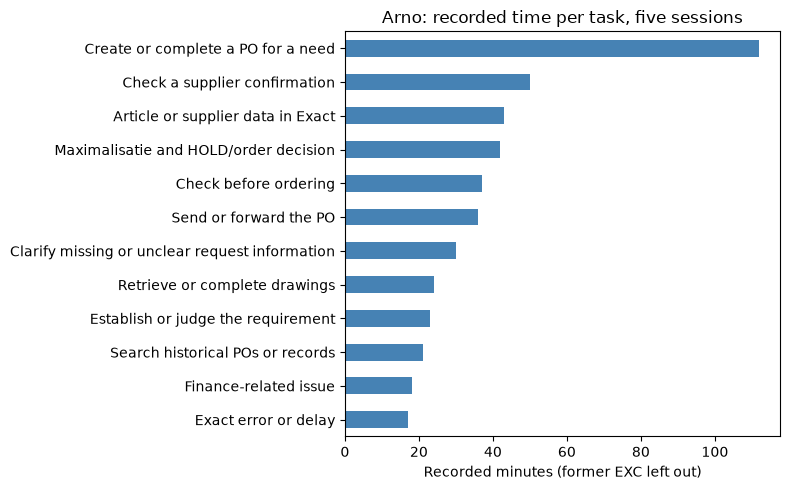

In [21]:
# The twelve tasks with the most recorded minutes
top = task_profile.head(12)

top["minutes"].sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    color="steelblue"
)

plt.xlabel("Recorded minutes (former EXC left out)")
plt.ylabel("")
plt.title("Arno: recorded time per task, five sessions")
plt.tight_layout()
plt.show()

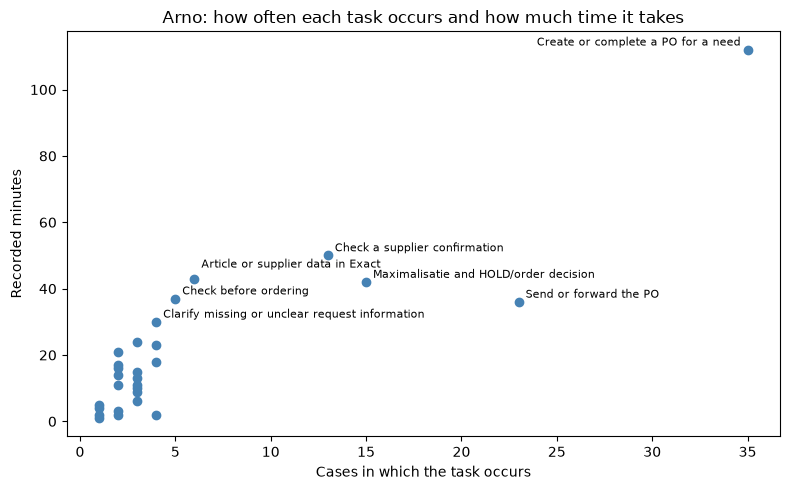

In [22]:
# Frequency against time: frequent tasks lie to the right, time-consuming ones higher up
timed_tasks = task_profile.dropna(subset=["minutes"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(timed_tasks["cases"], timed_tasks["minutes"], color="steelblue")

# Label the tasks with at least 30 minutes or at least 10 cases;
# two labels are moved so they do not overlap
moved = {
    "Create or complete a PO for a need": (-5, 3, "right"),
    "Article or supplier data in Exact": (5, 8, "left"),
}

for name, row in timed_tasks.iterrows():
    if row["minutes"] >= 30 or row["cases"] >= 10:
        dx, dy, align = moved.get(name, (5, 3, "left"))
        ax.annotate(name, (row["cases"], row["minutes"]),
                    xytext=(dx, dy), textcoords="offset points",
                    ha=align, fontsize=8)

ax.set_xlabel("Cases in which the task occurs")
ax.set_ylabel("Recorded minutes")
ax.set_title("Arno: how often each task occurs and how much time it takes")
plt.tight_layout()
plt.show()

**Reading.**

- **Creating or completing PO lines takes the most recorded time:** 112 minutes in 35 cases, on all five days, about 3 minutes per case.
- **Six tasks follow with 30 to 50 minutes each:** checking supplier confirmations (50 minutes, 13 cases, on 3 of the 5 days), article or supplier data in Exact (43 minutes, 6 cases), maximalisatie (42 minutes, 15 cases, every day), checks before ordering (37 minutes, 5 cases, every day), sending the PO (36 minutes, 23 cases) and clarifying missing or unclear information (30 minutes, 4 cases).
- **Frequent but short per case:** sending the PO (1.6 minutes per case) and maximalisatie (2.8). **Rare but long per case:** searching historical POs (10.5 minutes per case), drawings (8.0), clarifying missing information (7.5), checks before ordering (7.4) and article data (7.2).
- **Receiving a request** occurs in 48 cases but is recorded as tallies, so it has no measured time.
- **Former EXC work**, left out here, is mainly follow-up on existing orders (55 minutes) and logistics coordination (51 minutes).

**Limits.** The labels were assigned on 30 September from short notes, so they depend on how much each note says, and 12 rows have none; see part 4 for how reliable they are. A row with two kinds counts under both. Most tasks occur in only a few cases, so minutes per case are rough averages. The figures show where observed time went in five sessions, not what could be saved.

## 6. How does a case flow?

Part 5 counted tasks one record at a time. Many cases need several records, sometimes with other work in between, so this part follows the cases.

A case is one OBS number on one day (OBS numbers restart each day). For each case this part looks at the order of its activities, how many separate stretches of work it got, and where work was left when Arno switched to something else.

- A **stretch** is a run of consecutive records of the same case. A case with two stretches was **picked up again** after other work came in between.
- Former EXC records count when deciding whether a case was interrupted, because they did interrupt the work. They are left out of the sequences, and cases with only former EXC work are left out of this part.
- Sequences show only what happened inside the observation blocks. A case can have started before a block or continued after it.

In [23]:
# Go through each day in recorded order
flow = labelled.sort_values(["date", "source_row"]).copy()

# A new stretch starts when the previous record that day belonged to another case
flow["new_stretch"] = flow["case_ref"] != flow.groupby("date")["case_ref"].shift()
flow["stretch"] = flow.groupby("case_ref")["new_stretch"].cumsum()

def sequence(activities):
    """Activities in order, with repeats in a row shown once."""
    steps = []
    for activity in activities:
        if not steps or steps[-1] != activity:
            steps.append(activity)
    return " → ".join(steps)

# One row per case, using records inside the improvement scope
flow_scope = flow.loc[~flow["former_exc"]]

cases = flow_scope.groupby("case_ref").agg(
    records=("source_row", "size"),
    minutes=("minutes", lambda m: m.sum(min_count=1)),
    sequence=("activity_group", sequence)
)
cases["stretches"] = flow.groupby("case_ref")["stretch"].max()
cases["picked_up_again"] = cases["stretches"] > 1

print("All cases:", flow["case_ref"].nunique())
print("Cases with only former EXC work:", flow["case_ref"].nunique() - len(cases))
print("Cases in this section:", len(cases))

cases[["records", "minutes", "stretches"]].describe().round(1)

All cases: 117
Cases with only former EXC work: 19
Cases in this section: 98


,records,minutes,stretches
count,98.0,93.0,98.0
mean,2.5,6.0,1.4
std,1.6,5.2,0.6
min,1.0,1.0,1.0
25%,1.0,2.0,1.0
50%,2.0,5.0,1.0
75%,3.0,8.0,2.0
max,9.0,29.0,3.0


In [24]:
# Cases that were picked up again, compared with cases done in one stretch
pickup = cases.groupby("picked_up_again").agg(
    cases=("records", "size"),
    minutes=("minutes", "sum"),
    median_minutes=("minutes", "median")
)
pickup["share_of_minutes_pct"] = pickup["minutes"] / cases["minutes"].sum() * 100

print("Stretches per case:", cases["stretches"].value_counts().sort_index().to_dict())
pickup.round(1)

Stretches per case: {1: 69, 2: 21, 3: 8}


,cases,minutes,median_minutes,share_of_minutes_pct
picked_up_again,,,,
False,69,301.0,3.0,53.8
True,29,259.0,7.5,46.2


In [25]:
# The most common sequences of activities within a case
cases["sequence"].value_counts().head(10).to_frame("cases")

,cases
sequence,
PO,18
REQ → CLAR,8
CHECK,7
OTHER,5
SEND,5
REQ → PO → SEND,5
REQ → CLAR → SEND,4
REQ,4
PO → SEND,4


In [26]:
# In how many cases each activity appears, and how many show the full path
steps = cases["sequence"].str.split(" → ")

presence = pd.Series({
    activity: steps.apply(lambda s: activity in s).sum()
    for activity in ["REQ", "CLAR", "PO", "CHECK", "SEND", "OTHER", "DEC"]
}, name="cases")

full_path = steps.apply(lambda s: {"REQ", "PO", "SEND"} <= set(s)).sum()
print("Cases that show REQ, PO and SEND:", full_path, "of", len(cases))

presence.to_frame()

Cases that show REQ, PO and SEND: 16 of 98


,cases
REQ,48
CLAR,29
PO,50
CHECK,19
SEND,40
OTHER,19
DEC,3


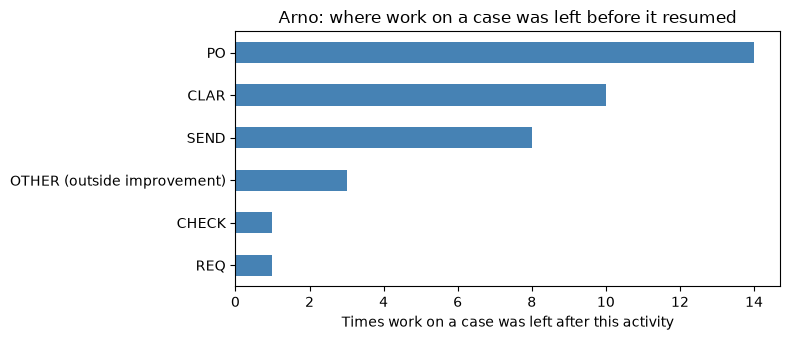

,times
activity_group,
PO,14
CLAR,10
SEND,8
OTHER (outside improvement),3
CHECK,1
REQ,1


In [27]:
# Where was work on a case left before it was picked up again?
last_of_stretch = flow.groupby(["case_ref", "stretch"])["activity_group"].last().reset_index()
last_stretch = flow.groupby("case_ref")["stretch"].max()

left_after = last_of_stretch.loc[
    last_of_stretch["case_ref"].isin(cases.index)
    & (last_of_stretch["stretch"] < last_of_stretch["case_ref"].map(last_stretch))
]

left_counts = left_after["activity_group"].value_counts()

left_counts.sort_values().plot(
    kind="barh",
    figsize=(8, 3.5),
    color="steelblue"
)

plt.xlabel("Times work on a case was left after this activity")
plt.ylabel("")
plt.title("Arno: where work on a case was left before it resumed")
plt.tight_layout()
plt.show()

left_counts.to_frame("times")

**Reading.**

- **98 cases** fall inside the improvement scope (117 in total; 19 contained only former EXC work). A typical case has 2 records and 5 recorded minutes (median); the longest took 29 minutes. Five cases have only untimed records.
- **29 cases (30%) were picked up again** after other work came in between: 21 had two stretches and 8 had three. They hold 259 of the 560 minutes (46%), with a median of 7.5 minutes per case against 3 for cases done in one stretch. The cases picked up again are the longer ones.
- **Work was most often left during PO work (14 times) or right after a clarification (10)**, and after sending (8). Leaving a case after a clarification may mean waiting for information from the requester or a colleague; the notes need checking case by case to confirm why.
- **Only 16 of the 98 cases show the whole path REQ → PO → SEND.** Most show part of it: a PO alone (18 cases), a request followed by a clarification (8), a check alone (7). Many cases started before or continued after an observation block, and some are separate tasks such as confirmation checks, so a partial sequence does not mean a step was skipped.

**Limits.** Cases are counted per day, so the two cases carried over from an earlier day (1 Sep `31AUG-OBS-07` and 18 Sep `OBS-01 (2026-08-31)`) count separately. "Picked up again" shows that other work came in between, not why it stopped. For POs, part 9 records one reason: Arno often leaves a non-urgent PO open on purpose to add later demand. Untimed tallies have no minutes.

## 7. Where do problems recur?

Part 6 showed that some cases stop and resume. This part asks which problems the notes record, and in which cases. A problem is a kind of work marked as a problem in part 4: missing or unclear information, drawings that had to be found or completed, an unavailable item, a Finance issue such as an unpaid invoice, a price difference, an Exact error, or a cancellation after ordering. Approval handling is not counted: three of its four records are routine forwarding of POs Johan approved. The one case where approval was needed again (18 Sep OBS-21) is mentioned in the reading.

For each problem type the table gives the cases and days where it occurs inside the improvement scope, its own records and minutes, the total minutes of those cases, and the share of those cases that was picked up again (part 6). The last column counts former EXC cases with the same problem; they are outside the improvement scope.

In [28]:
# Problem kinds and their short labels, from the kind map in part 4
problem_types = kind_map.loc[kind_map["problem"].ne(""), "problem"].to_dict()

# One line per record and problem type
problem_rows = labelled.assign(kind_id=labelled["kinds"].str.split(";")).explode("kind_id")
problem_rows = problem_rows.loc[problem_rows["kind_id"].isin(problem_types)].copy()
problem_rows["problem"] = problem_rows["kind_id"].map(problem_types)

inside = problem_rows.loc[~problem_rows["former_exc"]]
outside = problem_rows.loc[problem_rows["former_exc"]]

# Cases (from part 6) in which each problem occurs
problem_cases = inside.groupby("problem")["case_ref"].unique()

problem_profile = inside.groupby("problem").agg(
    cases=("case_ref", "nunique"),
    days=("date", "nunique"),
    records=("source_row", "size"),
    problem_minutes=("minutes", lambda m: m.sum(min_count=1))
)
problem_profile["case_minutes"] = problem_cases.apply(lambda c: cases.loc[c, "minutes"].sum())
problem_profile["picked_up_again_pct"] = problem_cases.apply(lambda c: cases.loc[c, "picked_up_again"].mean() * 100)
problem_profile["former_exc_cases"] = outside.groupby("problem")["case_ref"].nunique()
problem_profile["former_exc_cases"] = problem_profile["former_exc_cases"].fillna(0).astype(int)

problem_profile.sort_values(["cases", "case_minutes"], ascending=False).round(1)

,cases,days,records,problem_minutes,case_minutes,picked_up_again_pct,former_exc_cases
problem,,,,,,,
Missing or unclear information,4,3,6,30.0,34.0,25.0,0
Finance issue (e.g. unpaid invoice),4,2,6,18.0,20.0,25.0,4
Drawings to find or complete,3,2,6,24.0,38.0,100.0,0
Item unavailable,3,2,5,10.0,20.0,66.7,2
Exact error or delay,2,2,2,17.0,19.0,0.0,0
Cancellation after ordering,2,2,7,16.0,18.0,50.0,0
Price difference,2,1,2,11.0,13.0,50.0,1


In [29]:
# Cases with at least one problem compared with the other cases
cases["has_problem"] = cases.index.isin(inside["case_ref"])

comparison = cases.groupby("has_problem").agg(
    cases=("records", "size"),
    minutes=("minutes", "sum"),
    median_minutes=("minutes", "median"),
    picked_up_again_pct=("picked_up_again", "mean")
)
comparison["picked_up_again_pct"] = comparison["picked_up_again_pct"] * 100
comparison["share_of_minutes_pct"] = comparison["minutes"] / cases["minutes"].sum() * 100

comparison.round(1)

,cases,minutes,median_minutes,picked_up_again_pct,share_of_minutes_pct
has_problem,,,,,
False,79,406.0,4.0,26.6,72.5
True,19,154.0,8.0,42.1,27.5


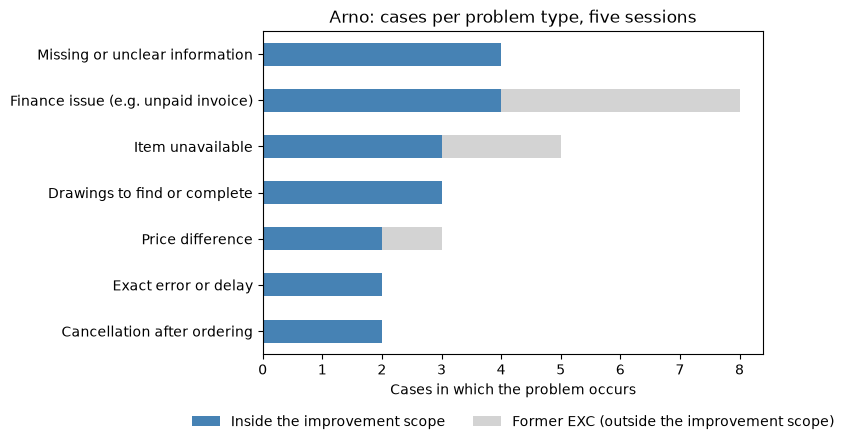

In [30]:
# Cases per problem type, inside the improvement scope and in former EXC work
plot_data = problem_profile[["cases", "former_exc_cases"]].rename(columns={
    "cases": "Inside the improvement scope",
    "former_exc_cases": "Former EXC (outside the improvement scope)"
}).sort_values("Inside the improvement scope")

plot_data.plot(
    kind="barh",
    stacked=True,
    figsize=(8, 4.6),
    color=["steelblue", "lightgray"]
)

plt.xlabel("Cases in which the problem occurs")
plt.ylabel("")
plt.title("Arno: cases per problem type, five sessions")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

In [31]:
# The records behind the table, for reading the notes
with pd.option_context("display.max_colwidth", 120, "display.max_rows", None):
    display(inside.sort_values(["problem", "date", "source_row"])[
        ["problem", "date", "Case", "activity_group", "minutes", "Note"]
    ])

,problem,date,Case,activity_group,minutes,Note
69,Cancellation after ordering,2026-09-01,OBS-04,REQ,NaN,Request to cancel one component because of long lead time and source it elsewhere.
70,Cancellation after ordering,2026-09-01,OBS-04,SEND,3.0,J+EXP: buyer judged the item non-interchangeable based on experience and copied a colleague for confirmation.
116,Cancellation after ordering,2026-09-08,OBS-01,SEND,1.0,"Arno was drafting mail, coincidentally Johan walk through"
117,Cancellation after ordering,2026-09-08,OBS-01,OTHER,4.0,Discuss with Johan; no mail.
118,Cancellation after ordering,2026-09-08,OBS-01,SEND,4.0,cancellation attmept for component
128,Cancellation after ordering,2026-09-08,OBS-01,SEND,NaN,Allow cancellation and respond; remaining wording unclear.
129,Cancellation after ordering,2026-09-08,OBS-01,PO,4.0,Adjust the corresponding PO.
179,Drawings to find or complete,2026-09-18,OBS-10,PO,7.0,Prepare drawings to attach to the PO; write down which drawings are missing.
180,Drawings to find or complete,2026-09-18,OBS-10,CLAR,2.0,Look for the relevant drawings and ask the engineer for them.
183,Drawings to find or complete,2026-09-18,OBS-11,CLAR,4.0,Relevant person unavailable; ask other colleagues. Also discuss the OBS-10 drawing.


**Reading.**

- **19 of the 98 cases contain at least one problem.** They take longer (median 8 minutes against 4), are picked up again more often (42% against 27%) and hold 27.5% of the recorded minutes.
- **No single problem dominates.** Each type occurs in only 2 to 4 cases inside the improvement scope, on 1 to 3 of the 5 days. Missing or unclear information occurs most often (4 cases on 3 days, 30 minutes), followed by Finance issues (4 cases), drawings (3 cases), unavailable items (3 cases), and Exact errors, cancellations and price differences (2 cases each).
- **Drawing cases were always picked up again:** in all 3, the notes record asking Engineering or a colleague for a drawing or information.
- **Half of the Finance cases are former EXC work** (4 of 8), outside the improvement scope. Inside the scope, one blocked a price check before ordering (1 Sep OBS-18).
- **Approval** was needed again once, after a mismatch in a 29-line pre-order check (18 Sep OBS-21).

**Limits.** Problems are only counted where a note records them, so short or unexplained notes can hide problems. With 2 to 4 cases per type, the numbers show which problems occurred, not how often they occur in general. A longer case is not necessarily caused by its problem: case length also depends on order size and how much of the case fell inside an observation block.

## 8. Comparing the improvement candidates

Parts 5 to 7 described tasks, cases and problems. This part brings that evidence together for each improvement candidate.

The [methodology](https://github.com/Luuuuuig/Bachelor-End-Project/blob/main/docs/methodology/Phase_1_Current_Methodology.md#53-formal-two-stage-selection-rule) selects the focal case in two stages: veto gates first (Stage A), then a weighted comparison on seven criteria (Stage B). Scoring anchors and weights are agreed with the supervisor **before** totals or a ranking are calculated, so this part does not score or rank.

It fills in what the observations can show: **observed workload contribution** and **repetition**, for each candidate in the methodology's portfolio. Article or supplier data in Exact is added because it is one of the larger tasks but has no candidate yet. Former EXC work is left out.

- A candidate's records are those showing at least one of its kinds of work; a record can belong to two candidates, so minutes are not added across candidates.
- Shares are of the 560 recorded minutes inside the improvement scope.
- "Picked up again" uses the cases from part 6.

In [32]:
# Kinds of work behind each candidate (see the methodology's candidate portfolio)
candidates = {
    "Purchase-price control": {"K04", "K17", "K18"},
    "Order timing / maximalisatie": {"K03"},
    "Request intake & validation": {"K08", "K09", "K10", "K11"},
    "Article or supplier data in Exact (not yet a candidate)": {"K12"},
    "PO supplier communication (supporting)": {"K05"},
    "Creating or completing PO lines (process redesign)": {"K02"},
}

scope_rows = labelled.loc[~labelled["former_exc"]].copy()
scope_rows["kind_set"] = scope_rows["kinds"].str.split(";").apply(set)
scope_minutes = scope_rows["minutes"].sum()

evidence = []
for name, kind_ids in candidates.items():
    rows = scope_rows.loc[scope_rows["kind_set"].apply(lambda s: bool(s & kind_ids))]
    case_ids = rows["case_ref"].unique()
    evidence.append({
        "candidate": name,
        "records": len(rows),
        "minutes": rows["minutes"].sum(),
        "share_pct": rows["minutes"].sum() / scope_minutes * 100,
        "cases": len(case_ids),
        "days": rows["date"].nunique(),
        "median_minutes_per_case": rows.groupby("case_ref")["minutes"].sum(min_count=1).median(),
        "picked_up_again_pct": cases.loc[case_ids, "picked_up_again"].mean() * 100,
    })

evidence = pd.DataFrame(evidence).set_index("candidate").sort_values("minutes", ascending=False)
evidence.round(1)

,records,minutes,share_pct,cases,days,median_minutes_per_case,picked_up_again_pct
candidate,,,,,,,
Creating or completing PO lines (process redesign),43,112.0,20.0,35,5,2.0,54.3
Purchase-price control,23,98.0,17.5,19,5,4.0,52.6
Request intake & validation,19,94.0,16.8,11,5,6.0,36.4
Article or supplier data in Exact (not yet a candidate),17,43.0,7.7,6,4,5.5,16.7
Order timing / maximalisatie,18,42.0,7.5,15,5,2.0,33.3
PO supplier communication (supporting),23,36.0,6.4,23,4,1.0,43.5


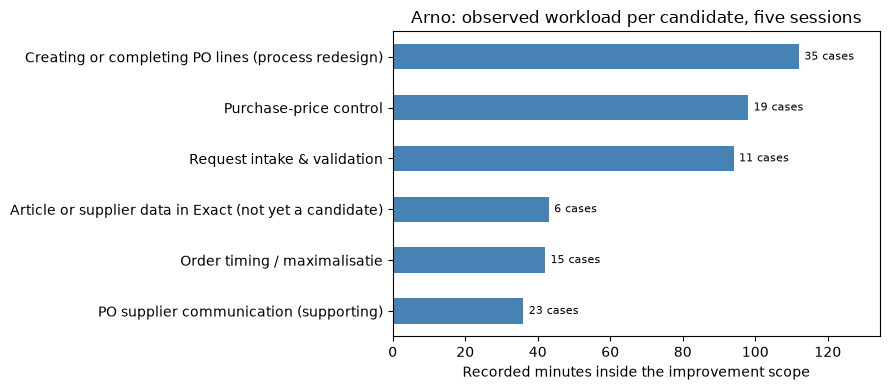

In [33]:
# Recorded minutes per candidate, with the number of cases in the label
ax = evidence["minutes"].sort_values().plot(
    kind="barh",
    figsize=(9, 4),
    color="steelblue"
)

for i, (name, row) in enumerate(evidence.sort_values("minutes").iterrows()):
    ax.annotate(f"{int(row['cases'])} cases", (row["minutes"], i),
                xytext=(4, 0), textcoords="offset points", va="center", fontsize=8)

ax.set_xlim(0, evidence["minutes"].max() * 1.2)
plt.xlabel("Recorded minutes inside the improvement scope")
plt.ylabel("")
plt.title("Arno: observed workload per candidate, five sessions")
plt.tight_layout()
plt.show()

In [34]:
# Standard-case boundary (methodology gate 6): cases done in one stretch without a recorded problem
routine = ~cases["has_problem"] & ~cases["picked_up_again"]

print("Cases done in one stretch without a recorded problem:", routine.sum(), "of", len(cases),
      f"({routine.mean() * 100:.0f}%)")
print("Their minutes:", cases.loc[routine, "minutes"].sum(), "of", cases["minutes"].sum(),
      f"({cases.loc[routine, 'minutes'].sum() / cases['minutes'].sum() * 100:.0f}%)")

Cases done in one stretch without a recorded problem: 58 of 98 (59%)
Their minutes: 228.0 of 560.0 (41%)


In [35]:
# The same boundary without the stretch condition: a case picked up again can still be standard,
# because Arno often leaves a non-urgent PO open on purpose (part 9)
no_problem = ~cases["has_problem"]

print("Cases without a recorded problem:", no_problem.sum(), "of", len(cases),
      f"({no_problem.mean() * 100:.0f}%)")
print("Their minutes:", cases.loc[no_problem, "minutes"].sum(), "of", cases["minutes"].sum(),
      f"({cases.loc[no_problem, 'minutes'].sum() / cases['minutes'].sum() * 100:.1f}%)")

Cases without a recorded problem: 79 of 98 (81%)
Their minutes: 406.0 of 560.0 (72.5%)


**What the observations cannot show.** The other Stage B criteria (business value beyond counted workload, data readiness, prototype feasibility, evaluation feasibility) need company input and access checks, and no Stage A gate has been assessed yet. The table records a first view of AI–task fit and the main open gate per candidate, to guide those checks.

| Candidate | AI–task fit, first view | What is known | Main open gate |
|---|---|---|---|
| Purchase-price control | Reading quotations and supplier confirmations and matching their lines to the PO: extraction and comparison of unstructured documents (Tater et al., 2022; Šimsa et al., 2023). Once data are structured, some checks could be plain rules. | Quotations arrive on paper, as PDF or from websites; confirmations by email. The correct price and date per line give a fairly clear reference. About 0.87 minutes per line (exploratory). | Access to confirmations, quotations and Exact PO data for development and testing (gates 1–3), and whether AI adds value beyond rules (gate 6). |
| Request intake & validation | Finding drawings and information, and flagging what is missing or ambiguous (Lombardi et al., 2025, for drawing search). | Varied work: drawings, quantities, historical POs, judging the requirement. Fewer but longer cases. | Where drawings and requests are stored and whether they can be used (gates 1–2), and what counts as a complete request (gate 3). |
| Order timing / maximalisatie | Support for deciding whether to combine demand and when to order (decision selection in Parasuraman et al., 2000). | Short cases with a recorded hold-or-order judgement. | What Exact's Advies already provides, and a defensible benchmark for a good decision (gate 3). |
| Article or supplier data in Exact | Extracting item fields from supplier documents (Šimsa et al., 2023). | One of 6 cases could not be finished because data were missing. | Whether it belongs under request intake & validation, and which Exact fields are required. |
| PO supplier communication | Low: forwarding the generated PO with a standard message is routine, and simple automation may be enough. | Many very short cases. | Probably fails the non-trivial AI fit gate (gate 6); the methodology already treats it as a supporting quick win. |
| Creating or completing PO lines (process redesign) | An exception-based workflow: routine cases handled with rules or AI, exceptions left to the buyer. | The buyers' concern of 1 October about AI preparing orders on its own sets a boundary. | Exception safety and buyer acceptance (gate 4), and rules for recognising standard cases. |

**Reading (observed workload only, not a ranking).**

- **Three candidates each hold 17–20% of the recorded minutes inside the scope** and occur on every day: creating or completing PO lines (112 minutes), purchase-price control (98) and request intake & validation (94). Article data, maximalisatie and PO communication hold 6–8% each.
- **They differ in shape.** PO lines and maximalisatie are many short cases (median 2 minutes); request intake and article data are fewer, longer cases (median 5.5–6 minutes); price control sits in between (4 minutes). PO-line and price-control cases are picked up again most often (53–54%).
- **Between 59% and 81% of cases look standard.** 58 cases (59%, holding 41% of the minutes) were done in one stretch without a recorded problem. But POs are often left open on purpose (part 9), so a case picked up again can still be standard. Counting only recorded problems gives 79 cases (81%), holding 72.5% of the minutes. This is a first indication of how much work could count as standard.
- Observed workload is one of seven criteria (25% in the provisional weights), so these figures do not select a candidate on their own.

**Next.**

1. Agree the scoring anchors and weights with Zhongxin before any scores are combined.
2. Decide whether article or supplier data joins request intake & validation.
3. Check the Stage A gates for the three largest candidates, starting with data access: confirmations and quotations for price control, drawings and requests for intake & validation, and Exact for PO lines.
4. Check the coding of the kinds of work (part 4) before these figures are scored.
5. Use the [AI function table](https://github.com/Luuuuuig/Bachelor-End-Project/blob/main/docs/methodology/AI_Function_Comparison_2026-10-02.md) for AI–task fit and buyer acceptance.

## 9. Why does the time go there? Draft root causes

Parts 5 to 8 show **where** the time goes. This part asks **why**, which is the core of the Analyze phase. It uses a cause-and-effect (fishbone) diagram for each of the three largest candidates from part 8. Each diagram groups possible causes into six categories:

- input information;
- method and rules;
- Exact;
- people and knowledge;
- other people and departments;
- suppliers.

Every cause is marked with where its evidence comes from:

- **(O) Observed:** recorded in the five baseline sessions; the source names the cases.
- **(E) Earlier notes:** recorded in the August exploratory sessions, mostly Arno's own explanations.
- **(R) Reported:** answered by Yijie on 2 October 2026, from earlier conversations with Arno and Dennis or his own observation. The answer names the person where Yijie did.
- **(H) Hypothesis:** not recorded anywhere yet.

Part 7 showed that problems are spread thin and that cases without a recorded problem hold 72.5% of the minutes. So the causes cannot come from problems alone. The first step therefore checks, per candidate, how much of its time falls in cases with a recorded problem.

The causes started as drafts built from the notes. On 2 October Yijie answered most of the questions prepared for Arno. The table below records each cause's status after those answers. They become root causes once Arno has confirmed them (see the [session guide](https://github.com/Luuuuuig/Bachelor-End-Project/blob/main/docs/measurement/Arno_Follow_Up_Session_Guide_2026-10-02.md)).

In [36]:
# How much of each candidate's time falls in cases with a recorded problem (part 7)?
focus = [
    "Creating or completing PO lines (process redesign)",
    "Purchase-price control",
    "Request intake & validation",
]

problem_case_ids = cases.index[cases["has_problem"]]

split = []
for name in focus:
    rows = scope_rows.loc[scope_rows["kind_set"].apply(lambda s: bool(s & candidates[name]))]
    in_problem_case = rows["case_ref"].isin(problem_case_ids)
    split.append({
        "candidate": name,
        "minutes": rows["minutes"].sum(),
        "minutes_in_problem_cases": rows.loc[in_problem_case, "minutes"].sum(),
        "cases": rows["case_ref"].nunique(),
        "cases_with_problem": rows.loc[in_problem_case, "case_ref"].nunique(),
    })

split = pd.DataFrame(split).set_index("candidate")
split["share_in_problem_cases_pct"] = split["minutes_in_problem_cases"] / split["minutes"] * 100

split.round(1)

,minutes,minutes_in_problem_cases,cases,cases_with_problem,share_in_problem_cases_pct
candidate,,,,,
Creating or completing PO lines (process redesign),112.0,18.0,35,6,16.1
Purchase-price control,98.0,26.0,19,5,26.5
Request intake & validation,94.0,53.0,11,7,56.4


**Reading.** The three candidates differ:

- **Creating or completing PO lines and purchase-price control** spend most of their time in cases without a recorded problem (84% and 73% of their minutes). Their causes should be looked for in how every order is handled.
- **Request intake & validation** spends more than half of its time in cases with a recorded problem (56%). This is partly by definition: two of its four kinds, clarifying missing information and finding drawings, count as problems themselves. Its causes should be looked for in the input it receives.

### The draft causes

Each cause is first listed with its source, so it can be traced back to the notes. The diagrams below then show the causes by category.

In [37]:
# Draft causes per candidate, with their status after Yijie's answers of 2 October
causes = pd.DataFrame.from_records([
    # Creating or completing PO lines
    ("PO-1", "Creating or completing PO lines (process redesign)", "Method and rules",
     "Each line is entered in Exact by hand", "Observed",
     "PO records on all five days (43 with K02)",
     "Not a main cause", "Entering lines is usually quick; it takes long when information is incomplete or wrong in Exact"),
    ("PO-2", "Creating or completing PO lines (process redesign)", "Method and rules",
     "Demand is added to open POs (maximalisatie), so POs are reopened", "Observed",
     "1 Sep OBS-27 (four lines added with MAX); 18 Sep OBS-21; 23 Sep notes",
     "Supported", "Lines are added when a PO for that supplier already exists"),
    ("PO-3", "Creating or completing PO lines (process redesign)", "Method and rules",
     "Non-urgent POs are left open on purpose to add later demand", "Reported",
     "Replaces the hypothesis that the reason was unknown; 23 Sep notes",
     "Supported", "Arno: he runs maximalisatie right after creating a PO; if it is not urgent he leaves it for more, "
     "or merges a new request from another department and sends. Dennis: each PO costs time and money"),
    ("PO-4", "Creating or completing PO lines (process redesign)", "Input information",
     "Drawings or item details turn out to be missing during entry", "Observed",
     "18 Sep OBS-10 (drawings missing); 18 Sep OBS-11 (one line added, further enquiry needed)",
     "Supported", "Entry takes long mainly when information is incomplete"),
    ("PO-5", "Creating or completing PO lines (process redesign)", "System (Exact)",
     "Exact errors and delays", "Observed",
     "31 Aug OBS-02 (error when sending); 23 Sep OBS-09 (12-minute fault); 23 Sep OBS-14 (delay)",
     "Not yet discussed", ""),
    ("PO-6", "Creating or completing PO lines (process redesign)", "System (Exact)",
     "Articles must first be created in Exact, by Arno or Dennis", "Observed",
     "8 Sep OBS-10 (Katja asked to add a supplier); 31 Aug OBS-07",
     "Changed", "Articles are created by Arno or Dennis; suppliers mostly by Dennis (tactical work), rarely by Arno"),
    ("PO-7", "Creating or completing PO lines (process redesign)", "People and knowledge",
     "Interruptions by calls, email and colleagues", "Observed",
     "INT marked on 16 records; 28 Aug pilot notes on fragmented cases",
     "Not yet discussed", ""),
    ("PO-8", "Creating or completing PO lines (process redesign)", "Other people and departments",
     "POs above Arno's €10,000 limit need Johan's approval", "Observed",
     "18 Sep OBS-21 (waiting for fiatteren); approval route described in the 21 Aug notes",
     "Supported", "Arno's limit is €10,000"),
    ("PO-9", "Creating or completing PO lines (process redesign)", "Other people and departments",
     "Colleague or requester unavailable, so the case is left", "Observed",
     "31 Aug OBS-13; 18 Sep OBS-11",
     "Not yet discussed", ""),
    ("PO-10", "Creating or completing PO lines (process redesign)", "Suppliers",
     "Item unavailable, so the line moves to another PO or supplier", "Observed",
     "8 Sep OBS-10; 18 Sep OBS-05 and OBS-09; 23 Sep OBS-12",
     "Not yet discussed", ""),
    ("PO-11", "Creating or completing PO lines (process redesign)", "Other people and departments",
     "Colleagues' data mistakes in Exact need checks to avoid ordering twice", "Reported",
     "New on 2 Oct",
     "New", "For example a component not linked to its production order; Arno then needs an extra "
     "clarification to avoid ordering the same component twice"),

    # Request intake & validation
    ("RI-1", "Request intake & validation", "Input information",
     "Requests arrive informally by email, at the desk or by phone", "Observed",
     "Request channels in the REQ codes",
     "Changed", "REQ-Exact records are POs Arno generated earlier, not requests"),
    ("RI-2", "Request intake & validation", "Input information",
     "Quantity or option is unclear", "Observed",
     "31 Aug OBS-01 (20 ml or 1000 ml); 1 Sep OBS-02 (18 or 2 × 18)",
     "Supported", "For example Primer-C: not clear which option is best"),
    ("RI-3", "Request intake & validation", "Input information",
     "Item details are missing, such as a machine's serial number for a service order", "Observed",
     "1 Sep OBS-12 (size not supplied); 8 Sep OBS-09 (photo)",
     "Changed", "Arno then searches old POs or calls the colleague"),
    ("RI-4", "Request intake & validation", "Input information",
     "Information from the requester can be wrong", "Earlier notes",
     "20 Aug: a suspicious serial number took 10–15 minutes to check, against 5 minutes of entry",
     "Not yet discussed", ""),
    ("RI-5", "Request intake & validation", "Method and rules",
     "No standard request form: requests come by email, desk or phone", "Reported",
     "Replaces the hypothesis of no standard form",
     "Supported", "Most requests come by email, at the desk or by phone"),
    ("RI-6", "Request intake & validation", "Method and rules",
     "Unclear who creates new articles", "Observed",
     "1 Sep OBS-17 (ownership checked with the purchasing manager)",
     "Rejected", "Articles are created by Arno or Dennis"),
    ("RI-7", "Request intake & validation", "System (Exact)",
     "Item hard to identify: old POs searched, several matches", "Observed",
     "1 Sep OBS-12; 23 Sep OBS-14",
     "Supported", "Old POs are searched, for example for a serial number, or the colleague is called"),
    ("RI-8", "Request intake & validation", "System (Exact)",
     "Item not yet in Exact, and the data to create it are missing", "Observed",
     "31 Aug OBS-07, continued on 1 Sep",
     "Not yet discussed", ""),
    ("RI-9", "Request intake & validation", "People and knowledge",
     "Judging suitability needs experience or a colleague", "Observed",
     "1 Sep OBS-04 (judged from experience); 8 Sep OBS-08 (fittings, to Dennis); 23 Sep OBS-14 (pressure rating, asked Emiel)",
     "Supported", "Primer-C: which option is best"),
    ("RI-10", "Request intake & validation", "Other people and departments",
     "Engineering's drawing set is incomplete", "Observed",
     "23 Sep OBS-12 (part of the set omitted); 18 Sep OBS-10; 28 Aug pilot",
     "Partly answered", "Specialised or customised items usually need drawings; why sets are incomplete is still open"),
    ("RI-11", "Request intake & validation", "Other people and departments",
     "Requester or colleague unavailable", "Observed",
     "31 Aug OBS-13; 18 Sep OBS-11",
     "Not yet discussed", ""),
    ("RI-12", "Request intake & validation", "Suppliers",
     "A quotation or supplier information is needed first", "Observed",
     "1 Sep OBS-12 (quotation requested)",
     "Not yet discussed", ""),

    # Purchase-price control
    ("PC-1", "Purchase-price control", "Method and rules",
     "Lines are compared one by one by hand", "Observed",
     "About 0.87 minutes per line (part 3); 18 Sep OBS-21 (29 lines, 20 minutes); 19 Aug notes",
     "Supported", "Exact cannot compare documents itself"),
    ("PC-2", "Purchase-price control", "Method and rules",
     "One-off and special items are checked before ordering", "Earlier notes",
     "20 Aug: Arno checks them so that an outdated price is not reused in later POs",
     "Not yet discussed", ""),
    ("PC-3", "Purchase-price control", "Method and rules",
     "Any change to a PO above €10,000 needs approval again", "Observed",
     "18 Sep OBS-21",
     "Changed", "After a change in Exact, a PO above Arno's €10,000 limit needs re-approval"),
    ("PC-4", "Purchase-price control", "Input information",
     "Prices come from paper, PDF, websites and email", "Observed",
     "8 Sep OBS-08 (paper quotation, then the website); confirmations by email, 19 Aug notes",
     "Not yet discussed", ""),
    ("PC-5", "Purchase-price control", "System (Exact)",
     "Prices in Exact are not kept up to date, because the buyers lack time", "Earlier notes",
     "19 and 20 Aug notes",
     "Supported", "Updates in Exact do not happen often. Dennis: prices should be updated regularly, but they are too busy"),
    ("PC-6", "Purchase-price control", "System (Exact)",
     "Exact cannot compare a confirmation with the PO", "Reported",
     "Replaces the hypothesis of no automatic comparison",
     "Supported", "Exact itself cannot compare; it is the software Arno works in"),
    ("PC-7", "Purchase-price control", "People and knowledge",
     "The cause of a mismatch in a long order is hard to find", "Observed",
     "18 Sep OBS-21",
     "Not yet discussed", ""),
    ("PC-8", "Purchase-price control", "Other people and departments",
     "Unpaid invoices block the supplier or the check", "Observed",
     "31 Aug OBS-16; 1 Sep OBS-18",
     "Not yet discussed", ""),
    ("PC-9", "Purchase-price control", "Other people and departments",
     "Finance returns cases without saying what is wrong", "Earlier notes",
     "19 Aug notes",
     "Outside the improvement scope", "Confirmed: it is unclear when and where something is missing. "
     "Finance-returned cases are invoice aftercare, outside the improvement scope since 1 October"),
    ("PC-10", "Purchase-price control", "Suppliers",
     "Supplier prices change, for example with material costs", "Earlier notes",
     "17 and 19 Aug notes",
     "Supported", "Supplier prices change dynamically"),
    ("PC-11", "Purchase-price control", "Suppliers",
     "Small order quantities cost more per unit", "Observed",
     "18 Sep OBS-29 (€410 difference, attributed in the notes to a small quantity)",
     "Not yet discussed", ""),
], columns=["id", "candidate", "category", "cause", "evidence", "source", "status", "answer_2_oct"]).set_index("id")

# Status of the causes after the answers of 2 October
pd.crosstab(causes["candidate"], causes["status"], margins=True)

status,Changed,New,Not a main cause,Not yet discussed,Outside the improvement scope,Partly answered,Rejected,Supported,All
candidate,,,,,,,,,
Creating or completing PO lines (process redesign),1,1,1,4,0,0,0,4,11
Purchase-price control,1,0,0,5,1,0,0,4,11
Request intake & validation,2,0,0,4,0,1,1,4,12
All,4,1,1,13,1,1,1,12,34


In [38]:
# All causes with their sources and the answers of 2 October
with pd.option_context("display.max_colwidth", 90, "display.max_rows", None):
    display(causes[["category", "cause", "evidence", "status", "answer_2_oct", "source"]])

,category,cause,evidence,status,answer_2_oct,source
id,,,,,,
PO-1,Method and rules,Each line is entered in Exact by hand,Observed,Not a main cause,Entering lines is usually quick; it takes long when information is incomplete or wrong...,PO records on all five days (43 with K02)
PO-2,Method and rules,"Demand is added to open POs (maximalisatie), so POs are reopened",Observed,Supported,Lines are added when a PO for that supplier already exists,1 Sep OBS-27 (four lines added with MAX); 18 Sep OBS-21; 23 Sep notes
PO-3,Method and rules,Non-urgent POs are left open on purpose to add later demand,Reported,Supported,Arno: he runs maximalisatie right after creating a PO; if it is not urgent he leaves i...,Replaces the hypothesis that the reason was unknown; 23 Sep notes
PO-4,Input information,Drawings or item details turn out to be missing during entry,Observed,Supported,Entry takes long mainly when information is incomplete,"18 Sep OBS-10 (drawings missing); 18 Sep OBS-11 (one line added, further enquiry needed)"
PO-5,System (Exact),Exact errors and delays,Observed,Not yet discussed,,31 Aug OBS-02 (error when sending); 23 Sep OBS-09 (12-minute fault); 23 Sep OBS-14 (de...
PO-6,System (Exact),"Articles must first be created in Exact, by Arno or Dennis",Observed,Changed,"Articles are created by Arno or Dennis; suppliers mostly by Dennis (tactical work), ra...",8 Sep OBS-10 (Katja asked to add a supplier); 31 Aug OBS-07
PO-7,People and knowledge,"Interruptions by calls, email and colleagues",Observed,Not yet discussed,,INT marked on 16 records; 28 Aug pilot notes on fragmented cases
PO-8,Other people and departments,"POs above Arno's €10,000 limit need Johan's approval",Observed,Supported,"Arno's limit is €10,000",18 Sep OBS-21 (waiting for fiatteren); approval route described in the 21 Aug notes
PO-9,Other people and departments,"Colleague or requester unavailable, so the case is left",Observed,Not yet discussed,,31 Aug OBS-13; 18 Sep OBS-11


In [39]:
import textwrap
from matplotlib.lines import Line2D

categories = ["Input information", "Method and rules", "System (Exact)",
              "People and knowledge", "Other people and departments", "Suppliers"]
colours = {"Observed": "steelblue", "Earlier notes": "darkorange",
           "Reported": "seagreen", "Hypothesis": "dimgray"}
tags = {"Observed": "O", "Earlier notes": "E", "Reported": "R", "Hypothesis": "H"}
left_out = ["Not a main cause", "Rejected", "Outside the improvement scope"]
answered = ["Supported", "Changed", "New"]

def fishbone(candidate):
    """Draw the causes of one candidate as a fishbone diagram."""
    data = causes.loc[(causes["candidate"] == candidate) & ~causes["status"].isin(left_out)]
    fig, ax = plt.subplots(figsize=(14, 7.5))
    ax.set_xlim(0, 16)
    ax.set_ylim(-6.3, 6.3)
    ax.axis("off")

    # Spine and effect, with the observed minutes and cases from part 8
    ax.annotate("", xy=(13.1, 0), xytext=(0.4, 0),
                arrowprops=dict(arrowstyle="-|>", lw=2, color="black"))
    name = candidate.split(" (")[0]
    effect = (textwrap.fill(name, 18) + "\n"
              f"{evidence.loc[candidate, 'minutes']:.0f} min, "
              f"{evidence.loc[candidate, 'cases']:.0f} cases")
    ax.text(13.2, 0, effect, ha="left", va="center", fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round", fc="white", ec="black"))

    # Three bones above the spine and three below
    for i, category in enumerate(categories):
        x = 3.4 + 4.0 * (i % 3)
        side = 1 if i < 3 else -1
        end_x, end_y = x - 1.6, 5.0 * side
        ax.plot([x, end_x], [0, end_y], color="black", lw=1.2)
        ax.text(end_x, end_y + 0.45 * side, category, ha="center", va="center",
                fontsize=10, fontweight="bold")

        rows = data.loc[data["category"] == category]
        for j, (_, row) in enumerate(rows.iterrows()):
            f = 0.86 - j * 0.23
            px, py = x + (end_x - x) * f, end_y * f
            colour = colours[row["evidence"]]
            ax.plot([px, px + 0.25], [py, py], color=colour, lw=1.5)
            label = f"({tags[row['evidence']]}) {row['cause']}"
            if row["status"] in answered:
                label += " ✓"
            ax.text(px + 0.32, py, textwrap.fill(label, 30), fontsize=9,
                    va="center", color=colour)

    present = [k for k in colours if k in data["evidence"].values]
    handles = [Line2D([0], [0], color=colours[k], lw=3, label=f"({tags[k]}) {k}") for k in present]
    handles.append(Line2D([0], [0], color="white", label="✓ supported by the answers of 2 October"))
    ax.legend(handles=handles, loc="lower right", fontsize=8, frameon=False)
    ax.set_title(f"Arno, causes to confirm: {name}", fontsize=12)
    plt.tight_layout()
    plt.show()

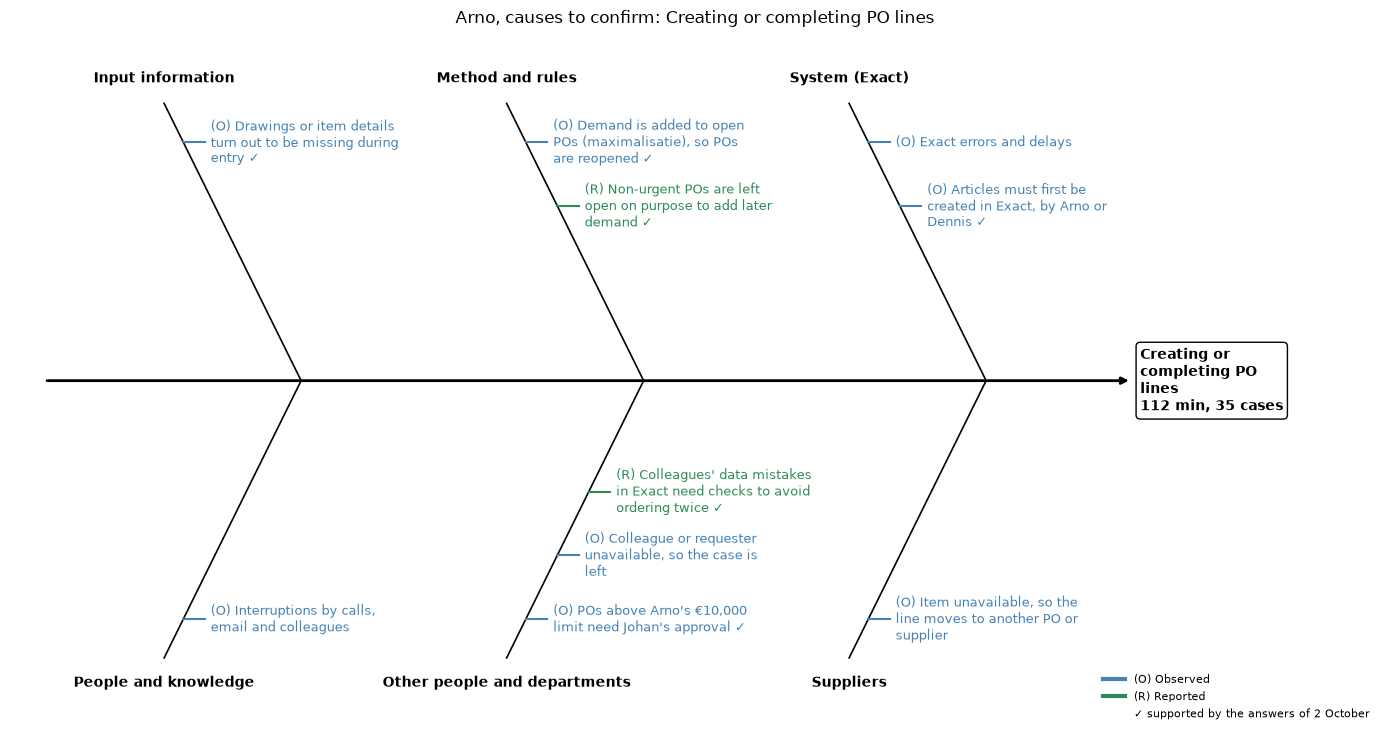

In [40]:
fishbone("Creating or completing PO lines (process redesign)")

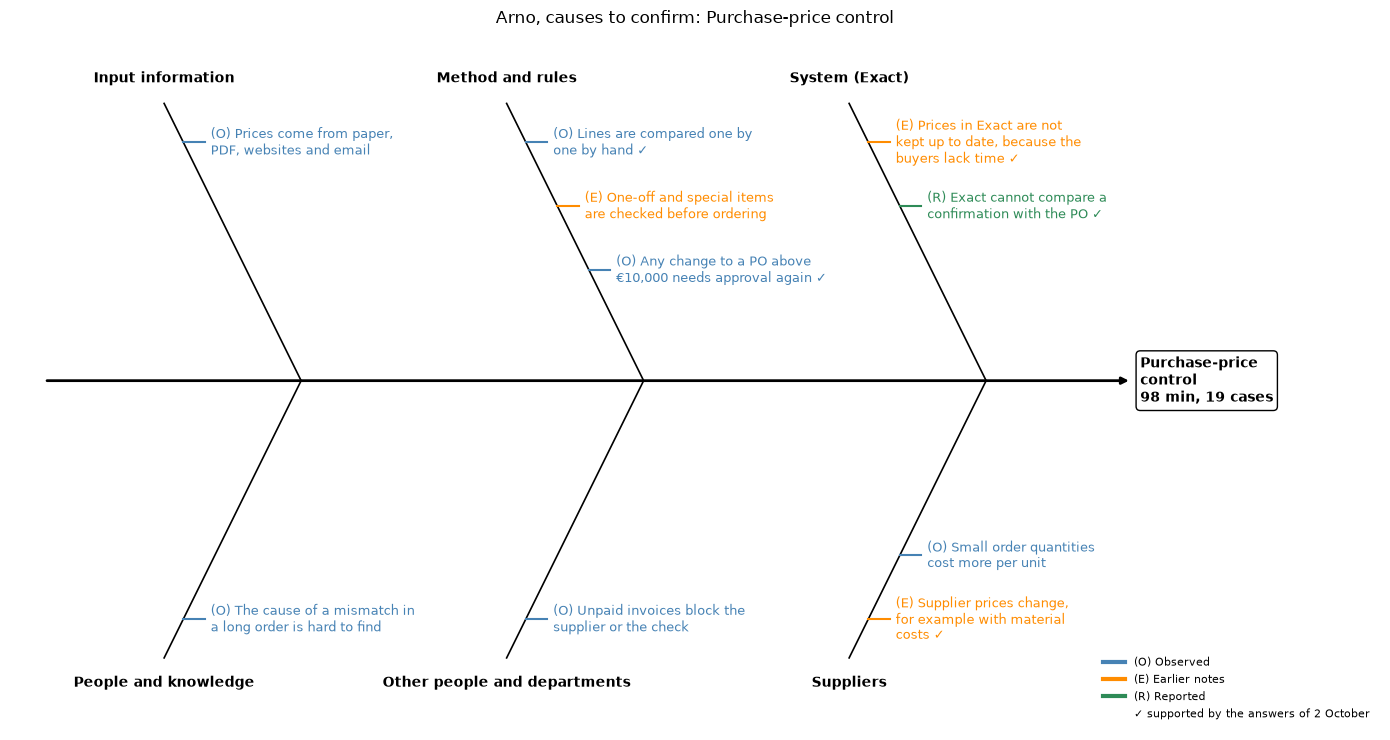

In [41]:
fishbone("Purchase-price control")

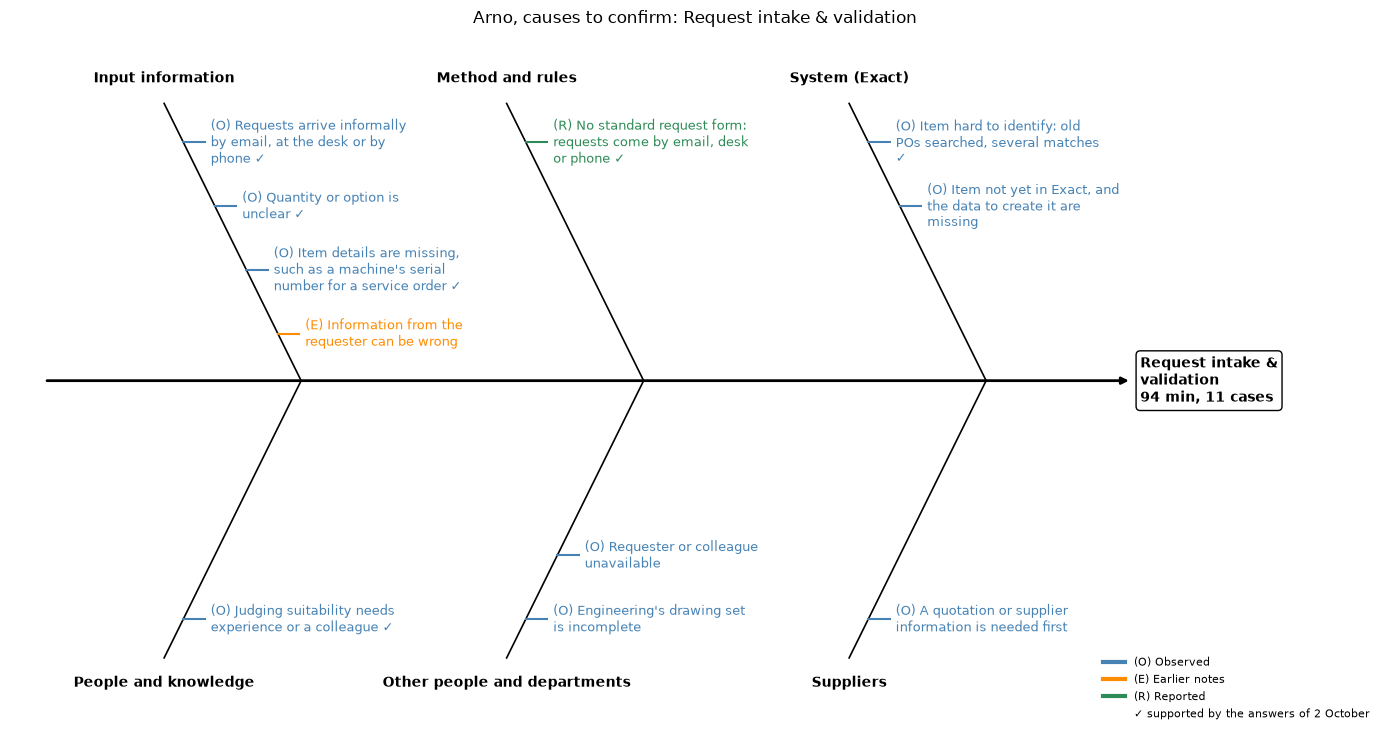

In [42]:
fishbone("Request intake & validation")

**What the answers of 2 October changed.**

- **POs are often left open on purpose.** Arno runs maximalisatie right after creating a PO. If the order is not urgent, he leaves it open to add later demand, or he merges a new request from another department and then sends it. Dennis adds that each PO costs time and money. So for POs, "picked up again" (part 6) often means a deliberate hold, not an interruption.
- **Entering PO lines is usually quick.** It takes long when information is incomplete, or when a colleague made a mistake in Exact, such as a component not linked to its production order. Arno then checks extra to avoid ordering the same component twice. This is a new cause.
- **Request intake has no clear single source.** Arno cannot say which requests are most often incomplete. Requests come informally by email, at the desk or by phone. The missing details are typically item information, such as a machine's serial number for a service order, or an unclear quantity or option (Primer-C).
- **"REQ-Exact" is not a request.** These records are cases that start from a PO Arno generated earlier. They carry the label "receive a request" (K01), which will be corrected together with the coding check of part 4.
- **Outdated prices have a deeper cause.** Prices in Exact should be updated regularly, but the buyers are too busy (Dennis). Exact cannot compare a confirmation with a PO, so every comparison is manual.
- **Re-approval.** Any change to a PO above Arno's €10,000 limit needs Johan's approval again.
- **Left out of the diagrams.** Finance returning unclear cases is confirmed, but it is invoice aftercare, outside the improvement scope since 1 October; the draft should not have included it. Unclear ownership of new articles is rejected: articles are created by Arno or Dennis, and suppliers mostly by Dennis. Typing the lines by hand is not a main cause.

**Reading.**

- **PO lines: the time is not in typing.** It goes to orders held open on purpose for maximalisatie, which is a choice to save the cost of extra POs, and to checks when information is incomplete or wrong in Exact.
- **Price control: manual comparison against prices that are not kept current.** Exact cannot compare documents, prices in Exact are not updated often, and supplier prices change. This is work every order needs, and part of its cause sits in the buyers' own upkeep of prices.
- **Request intake: incomplete input with no clear single source.** Missing serial numbers, unclear quantities and incomplete drawing sets come from different requesters, so fixing one source would not remove most of it.

**Limits.** The answers of 2 October come from Yijie's earlier conversations with Arno and Dennis, not from a session held for this purpose, and Arno still has to confirm them. The causes come from short notes and few cases. A diagram shows possible causes, not how much time each one costs. The first table of this part depends on the problem labels, which are not yet checked (part 4).

### What the causes suggest (for discussion, not decided)

The methodology asks Analyze to decide which work should be eliminated, simplified, standardised, automated or supported. A first view for the main causes:

| Cause | Where it sits | Possible direction | Role for AI, first view |
|---|---|---|---|
| Lines compared one by one, because Exact cannot compare documents | Every order | Support: read the documents, match the lines and flag differences | Good fit: document extraction and matching |
| Prices in Exact not kept up to date, for lack of time | The buyers' own upkeep of prices | Simplify: keep prices current; support by suggesting updates from recent confirmations | Possible |
| POs held open for maximalisatie | A deliberate choice to save the cost of extra POs | Keep; support could help find demand to combine (the maximalisatie candidate) | Possible: decision support |
| Colleagues' mistakes in Exact, such as unlinked components | Upstream: other departments | Fix at the source; support by flagging needs without a linked production order | Partial |
| Incomplete requests from different sources | Upstream: requesters | Standardise the request; support by flagging missing fields | Partial |
| Incomplete drawing sets | Upstream: Engineering | Fix at the source, for example with a list of required drawings; support with a completeness check | Partial |
| Unpaid invoices blocking suppliers | Upstream: Finance | Outside Purchasing | None |
| Any change to a PO above €10,000 needs re-approval | Approval rule | Simplify: finish the checks before approval | None |
| Interruptions and unavailable colleagues | Work organisation | Context; not something the solution addresses | None |

### Still open for Arno

The [session guide](https://github.com/Luuuuuig/Bachelor-End-Project/blob/main/docs/measurement/Arno_Follow_Up_Session_Guide_2026-10-02.md) now starts by asking Arno to confirm the answers above. What remains after that:

1. Why do drawing sets from Engineering sometimes miss drawings?
2. Roughly how many of his cases would he call routine, and what makes a case not routine? (Part 8 puts it between 59% and 81%.)
3. How does he find other demand to combine, for example through Exact's advice?
4. Is arranging certification with Lloyd purchasing work? What was the service order of 23 September about?
5. Which kinds of support he would accept (part D of the guide). These answers must come from Arno himself.

The 13 causes marked "Not yet discussed" stay as observed or noted; they can be checked when they come up.